<table style="width: 100%; border-collapse: collapse; border-bottom: 4px solid #003366;">
    <tr style="border: none;">
        <td style="border: none; text-align: left; vertical-align: middle; padding-bottom: 15px;">
            <h1 style="color: #003366; font-family: 'Helvetica', sans-serif; margin-top: 0; margin-bottom: 5px;"> IMT3410:  Métodos para Ecuaciones Diferenciales </h1>
            <h2 style="color: #555; margin-top: 10px; margin-bottom: 10px;">Capítulo 1: Métodos para ecuaciones diferenciales ordinarias</h2>
            <p style="margin: 2px 0;"><b>Profesor:</b> Manuel A. Sánchez </p>
            <p style="margin: 2px 0;"><b>Institución:</b> Instituto de Ingeniería Matemática y Computacional, Pontificia Universidad Católica de Chile</p>
            <p style="margin: 2px 0;"><b>Fecha:</b> Agosto, 2026</p>
        </td>
        <td style="border: none; text-align: right; vertical-align: middle; padding-bottom: 15px; width: 260px;">
            <!-- <img src="../source/FacMatematicas-15.png" alt="Logo UC" width="400" style="margin-bottom: 8px;"><br> -->
            <a href="https://colab.research.google.com/github/ManuelSanchezUribe/ManuelSanchezUribe.github.io/blob/main/Capitulo1.ipynb" target="_blank">
                <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab" width="120">
            </a>
        </td>
    </tr>
</table>
<br>
<div style="border: 1px solid #2980b9; border-left: 8px solid #2980b9; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2980b9; margin-top: 0;">Contenidos:</h3>
    <ul>
        <li>Poligonos de Euler</b>.</li>
        <li>Teorema de Peano.</li>
        <li>Metodos de Euler.</li>
    </ul>
</div>


<!-- Palette colors UC: celeste:#0176DE, azul #173F8A, azul oscuro: #03122E, amarillo: #FEC60D, amarillo oscuro: #E3AE00 -->
<!--
<figure>
<img align ="right" src="IMClogo.png" alt="logo" width="250" height="400"><br><br><br><br><br>
</figure>
 -->

## **Temas**
1. [Ejemplo: Poligonos de Euler](#Ejemplo:-Poligonos-de-Euler)
2. [Ejemplo: Teorema de existencia de Peano](#Ejemplo:-Teorema-de-existencia-de-Peano)
3. [Metodo de Euler explicito](#Metodo-de-Euler-explicito)
4. [Metodo de Euler implicito](#Metodo-de-Euler-implicito)
5. [Regla trapezoidal](#Regla-trapezoidal)
6. [Ejemplo: Cuando todo va bien](#Ejemplo:-Cuando-todo-va-bien)
7. [Ejemplo: Cuando falla](#Ejemplo:-Cuando-falla)
8. [Ejemplo: Convergencia](#Ejemplo:-Convergencia)
9. [Regla trapezoidal](#Regla-trapezoidal)
10. [Metodos de paso multiple](#Metodos-de-paso-multiple)
11. [Propiedad Cero Estable](#Propiedad-Cero-Estable)
12. [El metodo explicito mas preciso de 2 pasos](#El-metodo-explicito-mas-preciso-de-2-pasos)
13. [Sistemas de ecuaciones](#Sistemas-de-ecuaciones)
14. [Problemas rigidos o Stiff](#Problemas-rigidos-o-Stiff)
15. [Regiones de estabilidad](#Region-de-estabilidad)
16. [Ejemplo: sistema stiff](#Ejemplo:-sistema-stiff)

In [1]:
# Import libraries: 
import numpy as np # - numerical scientific computing NumPy
import scipy as scp # - scientific computing
import matplotlib.pyplot as plt # - visualiazation in python
import pandas as pd # - data analysis
from IPython.display import display, HTML
display(HTML("""<style>.output {display: flex;align-items: center;text-align: center;}</style>"""))

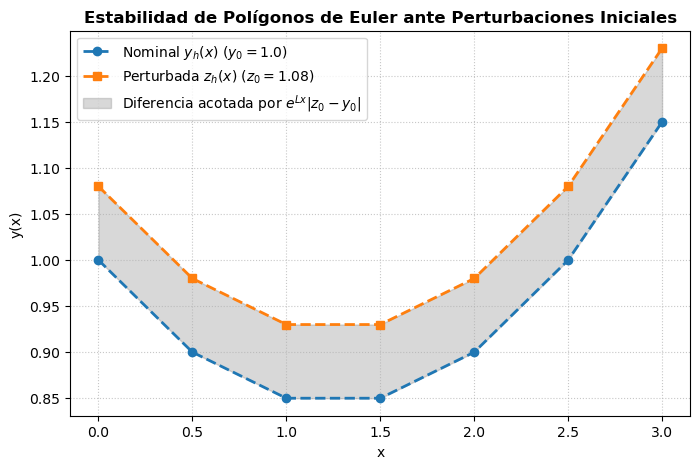

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. EJEMPLO: POLÍGONOS DE EULER Y ESTABILIDAD
# ==========================================
# Definición de la EDO: y' = f(x,y) = 0.2(x - 1)
f = lambda x, y: 0.2 * (x - 1)

def resolver_euler(x_grid, y0):
    """Resuelve el PVI usando el método de polígonos de Euler."""
    yh = np.zeros(x_grid.size)
    yh[0] = y0
    for j in range(x_grid.size - 1):
        dx = x_grid[j+1] - x_grid[j]
        yh[j+1] = yh[j] + dx * f(x_grid[j], yh[j])
    return yh

# Malla temporal
x_grid = np.linspace(0, 3, 7)

# Trayectoria nominal (y_0 = 1.0)
yh_nominal = resolver_euler(x_grid, y0=1.0)

# Trayectoria perturbada con condición inicial ligeramente distinta (z_0 = 1.08)
yh_perturbada = resolver_euler(x_grid, y0=1.08)

# Gráfico de sensibilidad / estabilidad ante condiciones iniciales usando colores por defecto de matplotlib
plt.figure(figsize=(8, 5))
plt.plot(x_grid, yh_nominal, '--o', linewidth=2, label='Nominal $y_h(x)$ ($y_0 = 1.0$)')
plt.plot(x_grid, yh_perturbada, '--s', linewidth=2, label='Perturbada $z_h(x)$ ($z_0 = 1.08$)')

# Relleno entre curvas para evidenciar la acotación de la distancia (Lema de Gronwall)
plt.fill_between(x_grid, yh_nominal, yh_perturbada, color='gray', alpha=0.3, label='Diferencia acotada por $e^{Lx} |z_0 - y_0|$')

plt.title("Estabilidad de Polígonos de Euler ante Perturbaciones Iniciales", fontweight='bold')
plt.xlabel("x")
plt.ylabel("y(x)")
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()


---
### 1. Polígonos de Euler: Convergencia y Refinamiento Progresivo

Para demostrar visualmente el **Lema de convergencia uniforme** visto en clases, resolveremos el siguiente Problema de Valor Inicial (PVI):
$$ y' = 0.2(x-1), \qquad y(0) = 1 $$

Cuya solución exacta, integrable directamente, es $y(x) = 0.1(x-1)^2 + 0.9$. 
El siguiente código implementa el método de Euler y grafica cómo la solución numérica se aproxima a la exacta al ir subdividiendo (refinando) un subintervalo a la vez, tal como se plantea en la demostración del teorema.

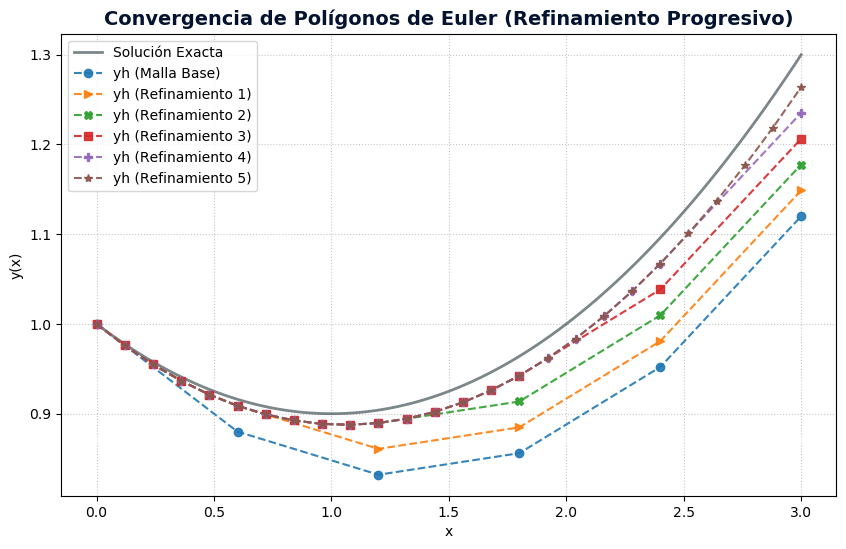

In [3]:
def solve_euler(x_grid, f, y0):
    """Resuelve un PVI usando el método de los polígonos de Euler dados los nodos x_grid."""
    yh = np.zeros(x_grid.size)
    yh[0] = y0
    for j in range(x_grid.size - 1):
        dxj = x_grid[j+1] - x_grid[j]
        yh[j+1] = yh[j] + dxj * f(x_grid[j], yh[j])
    return yh

# Definición del problema
f = lambda x, y: 0.2 * (x - 1)
y_exact = lambda x: 0.1 * (x - 1)**2 + 0.9

# Configuración del refinamiento
x_base = np.linspace(0, 3, 6)
nref = 6
mallas = [x_base]
nombres = ['yh (Malla Base)']

# Refinamiento progresivo: insertamos puntos intervalo por intervalo (como en la demostración teórica)
x_current = x_base.copy()
for i in range(len(x_base) - 1):
    idx = i * (nref - 1)
    x_ref = np.linspace(x_current[idx], x_current[idx+1], nref)
    # Concatenar: lado izquierdo + intervalo refinado + lado derecho
    x_current = np.concatenate((x_current[:idx], x_ref, x_current[idx+2:]))
    mallas.append(x_current)
    nombres.append(f'yh (Refinamiento {i+1})')

# Visualización
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
marcadores = ['o', '>', 'X', 's', 'P', '*']

# Graficar solución exacta
x_plot = np.linspace(0, 3, 100)
ax.plot(x_plot, y_exact(x_plot), color='#23373b', linestyle='-', linewidth=2, label='Solución Exacta', alpha=0.6)

# Graficar iteraciones de Euler
for i, (x_malla, nombre) in enumerate(zip(mallas, nombres)):
    yh = solve_euler(x_malla, f, y0=1.0)
    ax.plot(x_malla, yh, linestyle='--', marker=marcadores[i], label=nombre, alpha=0.9)

ax.set_title("Convergencia de Polígonos de Euler (Refinamiento Progresivo)", fontsize=14, fontweight='bold', color='#03122E')
ax.set_xlabel("x")
ax.set_ylabel("y(x)")
ax.legend()
ax.grid(True, linestyle=':', alpha=0.7)
plt.show()

---
### 2. Teorema de Existencia de Peano (Pérdida de Unicidad)

Si abandonamos la condición de Lipschitz, perdemos la garantía de unicidad. Consideremos la EDO patológica de la clase:
$$ y' = 4\left( \text{sign}(y)\sqrt{|y|} + \max \left(0, x-\frac{|y|}{x}\right)\cos\left(\frac{\pi \log(x)}{\log(2)}\right)\right), \quad y(0) = 0 $$

Al resolverla numéricamente con Euler para pasos sucesivos de la forma $h = 2^{-i}$, observaremos cómo las soluciones bifurcan hacia $y = 4x^2$ o $y = -4x^2$ dependiendo de la paridad de $i$, demostrando empíricamente que existen infinitas soluciones al PVI.

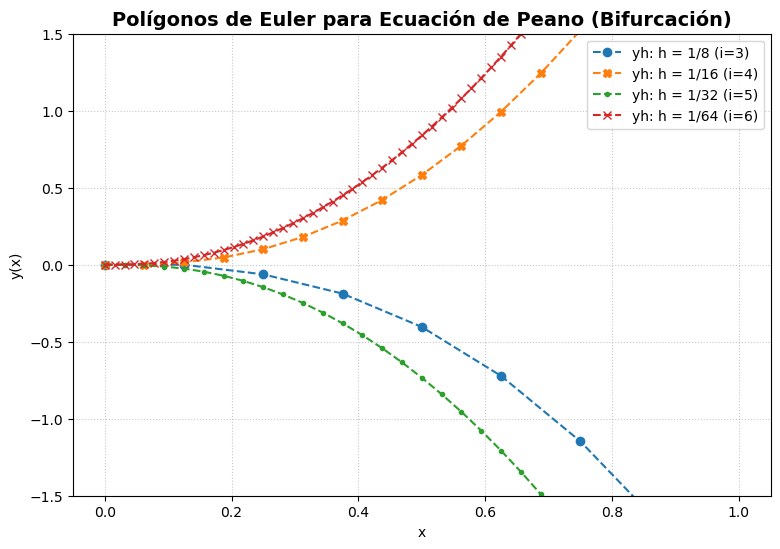

In [4]:
def funPeano(x, y):
    """Evaluación de la EDO patológica de Peano."""
    if x > 0:
        termino_1 = np.sign(y) * np.sqrt(np.abs(y))
        termino_2 = max(0, x - abs(y)/x) * np.cos(np.pi * np.log10(x) / np.log10(2.0))
        return 4.0 * (termino_1 + termino_2)
    else:
        return 0.0 # Por definición en x=0 para evitar división por cero

fig, ax = plt.subplots(1, 1, figsize=(9, 6))
marcadores_peano = ['o', 'X', '.', 'x']

# Evaluamos para h = 1/8, 1/16, 1/32, 1/64
for idx, i in enumerate(range(3, 7)):
    h = 1.0 / (2**i)
    x_grid = np.linspace(0, 1, 2**i + 1)
    yh = solve_euler(x_grid, funPeano, y0=0.0)
    ax.plot(x_grid, yh, linestyle='--', marker=marcadores_peano[idx], label=f'yh: h = 1/{2**i} (i={i})')

ax.set_title("Polígonos de Euler para Ecuación de Peano (Bifurcación)", fontsize=14, fontweight='bold')
ax.set_xlabel("x")
ax.set_ylabel("y(x)")
ax.set_ylim([-1.5, 1.5])
ax.legend()
ax.grid(True, linestyle=':', alpha=0.7)
plt.show()

---
### 3. Teorema de Picard-Lindelöf: Restricción del Cilindro de Existencia

El Teorema de Picard-Lindelöf impone un criterio geométrico para asegurar que las iteraciones no escapen del dominio seguro $D$. La condición estricta es:
$$ C \geq \frac{K}{L}\left(e^{LX_M} - 1\right) $$

Si normalizamos los parámetros ($K=L=1$) para simplificar, podemos despejar el intervalo de existencia máximo garantizado $X_M$ en función del radio del cilindro $C$:
$$ X_M(C) = \frac{1}{2(1+C)}\ln\left(1+2C(1+C)\right) $$

El siguiente gráfico busca el valor de $C$ que maximiza el intervalo de existencia teórica $X_M$.

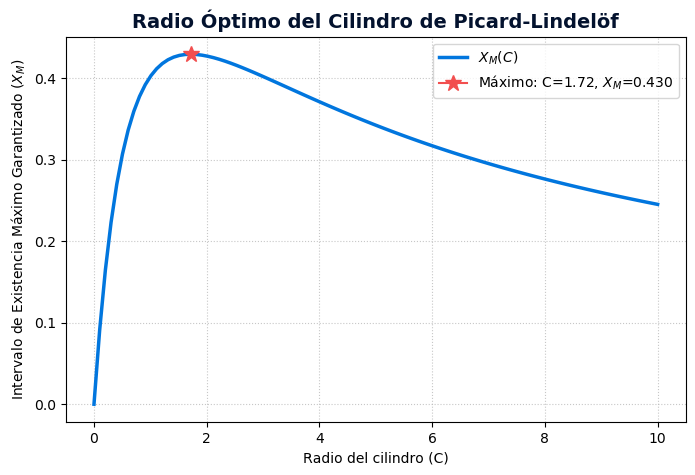

In [5]:
# Definición de la función de cota de intervalo máximo XM(C)
XM = lambda C: 1.0 / (2.0 * (1 + C)) * np.log(1 + 2 * C * (1 + C))

c_vals = np.linspace(0, 10, 100)
xm_vals = XM(c_vals)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(c_vals, xm_vals, color='#0176DE', linewidth=2.5, label=r'$X_M(C)$')

# Encontrar y graficar el punto máximo (óptimo)
c_opt = c_vals[np.argmax(xm_vals)]
xm_max = np.max(xm_vals)
ax.plot(c_opt, xm_max, marker='*', color='#F24F4F', markersize=12, label=f'Máximo: C={c_opt:.2f}, $X_M$={xm_max:.3f}')

ax.set_title("Radio Óptimo del Cilindro de Picard-Lindelöf", fontsize=14, fontweight='bold', color='#03122E')
ax.set_xlabel("Radio del cilindro (C)")
ax.set_ylabel("Intervalo de Existencia Máximo Garantizado ($X_M$)")
ax.legend()
ax.grid(True, linestyle=':', alpha=0.7)
plt.show()

## Solución del Ejercicio 1: Análisis del Teorema de Picard-Lindelöf

Considere el problema de valor inicial autónomo:
$$ y' = y^2, \qquad y(0) = 1 $$

### 1. Cálculo analítico de los primeros tres iterados de Picard
La construcción de las iteraciones sucesivas de Picard está dada por la relación integral de punto fijo:
$$ y_0(x) = y_0 = 1 $$
$$ y_n(x) = y_0 + \int_{0}^{x} (y_{n-1}(s))^2 \, ds, \quad n = 1, 2, 3, \ldots $$

* **Primer iterado ($y_1$):**
  $$ y_1(x) = 1 + \int_{0}^{x} (1)^2 \, ds = 1 + \int_{0}^{x} 1 \, ds = 1 + x $$

* **Segundo iterado ($y_2$):**
  $$ y_2(x) = 1 + \int_{0}^{x} (1 + s)^2 \, ds = 1 + \int_{0}^{x} (1 + 2s + s^2) \, ds = 1 + x + x^2 + \frac{x^3}{3} $$

* **Tercer iterado ($y_3$):**
  $$ y_3(x) = 1 + \int_{0}^{x} \left(1 + s + s^2 + \frac{s^3}{3}\right)^2 ds $$
  Expandiendo el binomio cuadrado del integrando y calculando la integral término a término, se obtiene:
  $$ y_3(x) = 1 + x + x^2 + x^3 + \frac{2}{3}x^4 + \frac{1}{3}x^5 + \frac{1}{9}x^6 + \frac{1}{63}x^7 $$

---



Eq(y_0(x), 1)

Eq(y_1(x), x + 1)

Eq(y_2(x), x**3/3 + x**2 + x + 1)

Eq(y_3(x), x**7/63 + x**6/9 + x**5/3 + 2*x**4/3 + x**3 + x**2 + x + 1)

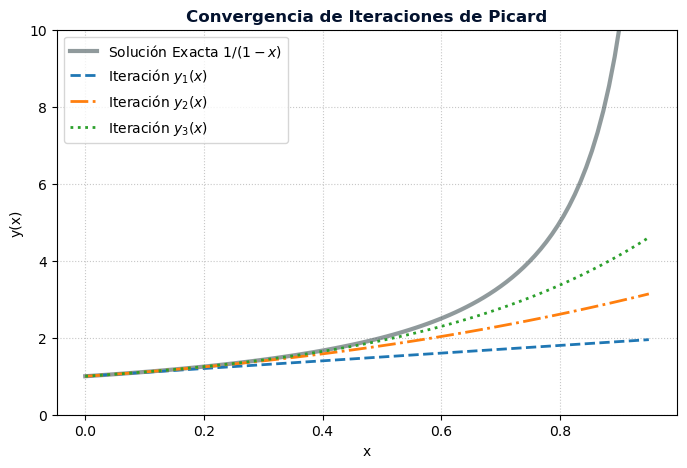

In [6]:
import sympy as sp

# Definición de símbolos
x, s = sp.symbols('x s')

# PVI: y' = f(y)
f = lambda y_val: y_val**2
y_0 = sp.Integer(1)

# Almacenar iteraciones
iteraciones = [y_0]

# Cálculo de iterados de Picard (n=1, 2, 3)
for i in range(1, 4):
    integrando = f(iteraciones[-1]).subs(x, s)
    y_next = 1 + sp.integrate(integrando, (s, 0, x))
    iteraciones.append(sp.expand(y_next))

# Imprimir resultados simbólicos
display(HTML("<b>Iteraciones de Picard obtenidas:</b>"))
for i, y_n in enumerate(iteraciones):
    display(sp.Eq(sp.Symbol(f'y_{i}(x)'), y_n))

# --- Visualización ---
# Convertir expresiones simbólicas a funciones numéricas (lambdify)
x_vals = np.linspace(0, 0.95, 100) # Evitamos x=1 para la solución exacta
y_exacta = 1 / (1 - x_vals)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
marcadores = ['-', '--', '-.', ':']

ax.plot(x_vals, y_exacta, color='#23373b', linewidth=3, label='Solución Exacta $1/(1-x)$', alpha=0.5)

for i in range(1, 4):
    func_num = sp.lambdify(x, iteraciones[i], 'numpy')
    ax.plot(x_vals, func_num(x_vals), linestyle=marcadores[i], linewidth=2, label=f'Iteración $y_{i}(x)$')

ax.set_title("Convergencia de Iteraciones de Picard", color='#03122E', fontweight='bold')
ax.set_xlabel("x")
ax.set_ylabel("y(x)")
ax.set_ylim([0, 10])
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend()
plt.show()



### 2. Intervalo maximal teórico de existencia para la solución analítica exacta
Para hallar la solución exacta, se separan variables en la EDO no lineal:
$$ \frac{dy}{y^2} = dx \implies \int \frac{dy}{y^2} = \int dx \implies -\frac{1}{y} = x + c $$
Aplicando la condición inicial $y(0) = 1$, determinamos la constante $c = -1$:
$$ -\frac{1}{y} = x - 1 \implies y(x) = \frac{1}{1 - x} $$
La función analítica exacta presenta una asíntota vertical (*blow-up* en tiempo finito) cuando $1 - x = 0$, es decir, en $x = 1$. Por lo tanto, el **intervalo maximal de existencia** para la solución orientada a $x \ge 0$ es el intervalo abierto **$[0, 1)$**.

---

### 3. Cota rigurosa de existencia mediante el Teorema de Picard-Lindelöf
Consideremos el dominio rectangular cerrado (cilindro de seguridad):
$$ D = \{ (x,y) : 0 \leq x \leq X, \, |y - 1| \leq C \} $$
Para aplicar la teoría del teorema, acotamos la función $f(y) = y^2$ y su derivada parcial en $D$:
* La función $f$ en el borde del dominio alcanza su valor máximo en $y = 1 + C$, por lo que la cota de la derivada en el punto inicial es $K = |f(1)| = 1^2 = 1$ (o bien $K = (1+C)^2$).
* La constante de Lipschitz $L$ se obtiene acotando la derivada parcial $\left|\frac{\partial f}{\partial y}\right| = |2y|$ en $D$, lo que da $L = 2(1 + C)$.

La condición estricta del teorema de Picard-Lindelöf para asegurar existencia y unicidad en el intervalo $[0, X]$ es:
$$ C \geq \frac{K}{L} \left( e^{LX} - 1 \right) $$
Sustituyendo $K = (1+C)^2$ y $L = 2(1+C)$ en la desigualdad:
$$ C \geq \frac{(1+C)^2}{2(1+C)} \left( e^{2(1+C)X} - 1 \right) \implies C \geq \frac{1+C}{2} \left( e^{2(1+C)X} - 1 \right) $$
Despejando el tiempo máximo garantizado $X$:
$$ \frac{2C}{1+C} \geq e^{2(1+C)X} - 1 \implies e^{2(1+C)X} \leq 1 + \frac{2C}{1+C} = \frac{1 + 3C}{1 + C} $$
Aplicando logaritmo natural en ambos lados:
$$ X \leq \frac{1}{2(1+C)} \ln\left( \frac{1 + 3C}{1 + C} \right) =: g(C) $$

* **Comparación con el tiempo de explosión real:** Si buscamos el radio óptimo $C$ que maximiza esta función $g(C)$ mediante cálculo diferencial ($g'(C) = 0$), se encuentra que el valor máximo garantizado del intervalo ocurre aproximadamente en $C \approx 1.714$, lo que arroja un tiempo garantizado de $X \approx 0.43$. 
* **Conclusión analítica:** El Teorema de Picard-Lindelöf garantiza existencia y unicidad de forma segura en el intervalo $[0, 0.43]$, el cual resulta ser **muy conservador** en comparación con el intervalo maximal real de existencia $[0, 1)$ debido a la naturaleza estrictamente suficiente (y no necesaria) de las cotas de Lipschitz.


---
### Ejercicio 2: Teorema de Picard-Lindelöf (Cilindro de Existencia)
Para el problema:
$$ y' = \sqrt{x} + y^2, \qquad y(0) = 0 $$
Evaluamos en el dominio $D = \{(x,y) : 0 \le x \le A, |y| \le B\}$. 
Sabemos que $K = \sqrt{A} + B^2$ y $L = 2B$. La restricción geométrica del teorema dicta que:
$$ A \le \frac{1}{2B} \ln\left(1 + \frac{2B^2}{\sqrt{A} + B^2}\right) $$

Para maximizar el intervalo de existencia $A$, resolveremos esta ecuación implícita buscando las raíces para distintos valores del radio $B$.

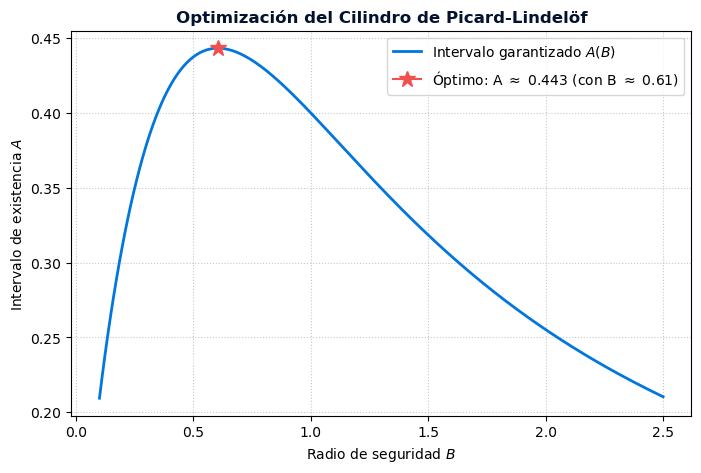

In [7]:
from scipy.optimize import root_scalar

def encontrar_A(B):
    """
    Encuentra la raíz A para la ecuación trascendente de Picard-Lindelöf dado un radio B.
    f(A) = (1 / 2B) * ln(1 + 2B^2 / (sqrt(A) + B^2)) - A = 0
    """
    def eq(A):
        return (1.0 / (2 * B)) * np.log(1 + (2 * B**2) / (np.sqrt(A) + B**2)) - A
    
    try:
        # Buscamos la raíz A en el intervalo [0, 2]
        sol = root_scalar(eq, bracket=[0, 2], method='brentq')
        return sol.root
    except ValueError:
        return 0.0

# Vectorizamos la evaluación para distintos tamaños del cilindro (B)
B_vals = np.linspace(0.1, 2.5, 200)
A_vals = [encontrar_A(B) for B in B_vals]

# Encontrar el óptimo
opt_idx = np.argmax(A_vals)
A_max = A_vals[opt_idx]
B_opt = B_vals[opt_idx]

# Graficar
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(B_vals, A_vals, color='#0176DE', linewidth=2, label='Intervalo garantizado $A(B)$')
ax.plot(B_opt, A_max, marker='*', color='#F24F4F', markersize=12, 
        label=f'Óptimo: A $\\approx$ {A_max:.3f} (con B $\\approx$ {B_opt:.2f})')

ax.set_title("Optimización del Cilindro de Picard-Lindelöf", color='#03122E', fontweight='bold')
ax.set_xlabel("Radio de seguridad $B$")
ax.set_ylabel("Intervalo de existencia $A$")
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend()
plt.show()

---
### Ejercicio 3: Verificación de un PVI 
Considere el siguiente problema de valor inicial del curso:
$$ u' = -2tu^2, \qquad 0 \le t \le 1, \qquad u(0) = 1 $$

La solución exacta es conocida y está dada por $u(t) = \frac{1}{1+t^2}$. Utilizaremos el método numérico de los polígonos de Euler para resolver este sistema computacionalmente y visualizaremos el decaimiento del error a medida que el paso $h \to 0$.

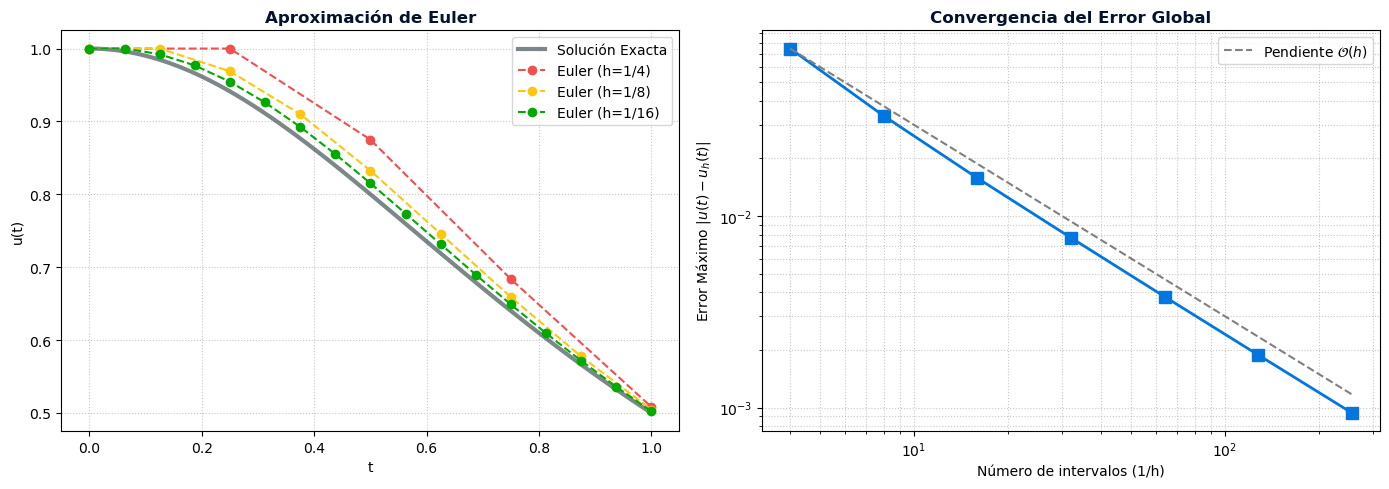

In [8]:
# Definición del problema
f_u = lambda t, u: -2 * t * u**2
u_exacta = lambda t: 1.0 / (1.0 + t**2)

# Función del Método de Euler
def poligonos_euler(t_grid, f, u0):
    uh = np.zeros(t_grid.size)
    uh[0] = u0
    for j in range(t_grid.size - 1):
        dt = t_grid[j+1] - t_grid[j]
        uh[j+1] = uh[j] + dt * f(t_grid[j], uh[j])
    return uh

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Solución numérica vs exacta
t_exacto = np.linspace(0, 1, 100)
ax1.plot(t_exacto, u_exacta(t_exacto), color='#23373b', linewidth=3, label='Solución Exacta', alpha=0.6)

pasos = [4, 8, 16]
colores = ['#F24F4F', '#FEC60D', '#00AA00']

for i, n_pasos in enumerate(pasos):
    t_num = np.linspace(0, 1, n_pasos + 1)
    u_num = poligonos_euler(t_num, f_u, u0=1.0)
    ax1.plot(t_num, u_num, '--o', color=colores[i], label=f'Euler (h=1/{n_pasos})')

ax1.set_title("Aproximación de Euler", fontweight='bold', color='#03122E')
ax1.set_xlabel("t")
ax1.set_ylabel("u(t)")
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

# Gráfico 2: Decaimiento del Error Global (Norma L-infinito)
n_eval = [2**i for i in range(2, 9)]
errores = []

for n in n_eval:
    t_num = np.linspace(0, 1, n + 1)
    u_num = poligonos_euler(t_num, f_u, u0=1.0)
    error_max = np.max(np.abs(u_num - u_exacta(t_num)))
    errores.append(error_max)

ax2.loglog(n_eval, errores, '-s', color='#0176DE', linewidth=2, markersize=8)
# Triángulo de pendiente teórica O(h)
ax2.loglog(n_eval, [errores[0]*(n_eval[0]/n)**1 for n in n_eval], '--', color='gray', label='Pendiente $\mathcal{O}(h)$')

ax2.set_title("Convergencia del Error Global", fontweight='bold', color='#03122E')
ax2.set_xlabel("Número de intervalos (1/h)")
ax2.set_ylabel("Error Máximo $|u(t) - u_h(t)|$")
ax2.grid(True, which="both", linestyle=':', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

---
## Metodo de Euler explicito

In [29]:
def Euler_explicito(odefun, t_span, y0, hfix, return_trajectory=False):
    '''
    Método de Euler explícito para resolver PVI: dy/dt = odefun(t, y), y(t0) = y0
    Inputs: - odefun : callable. Función que define la EDO f(t, y).
            - t_span : tuple. Intervalo de integración (t0, tf).
            - y0     : float o np.ndarray. Condición inicial.
            - hfix   : float. Tamaño de paso temporal. 
            - return_trajectory : bool, opcional. Si es True, retorna la trayectoria completa (t, y). Si es False, retorna solo el valor final (y_final, t_final).
    Output: - Si return_trajectory=True:  (t_array, y_array)
            - Si return_trajectory=False: (y_final, t_final)
    '''
    t0, tf = t_span
    t = t0
    y = np.array(y0, dtype=float) if isinstance(y0, (list, np.ndarray)) else float(y0)
    
    if return_trajectory:
        tn = [t0]
        yh = [y.copy() if isinstance(y, np.ndarray) else y]
        
        while tf - t > 1e-14:
            h = min(hfix, tf - t)
            y = y + h * odefun(t, y)
            t += h
            tn.append(t)
            yh.append(y.copy() if isinstance(y, np.ndarray) else y)
            
        return np.array(yh), np.array(tn)
    else:
        while tf - t > 1e-14:
            h = min(hfix, tf - t)
            y = y + h * odefun(t, y)
            t += h
        return y, t

## Ejemplo: considere el PVI
\begin{equation}
y' = 2x,\quad y(0) = 0 
\end{equation}
observe que la solucion exacta es $y(x) = x^{2}$.

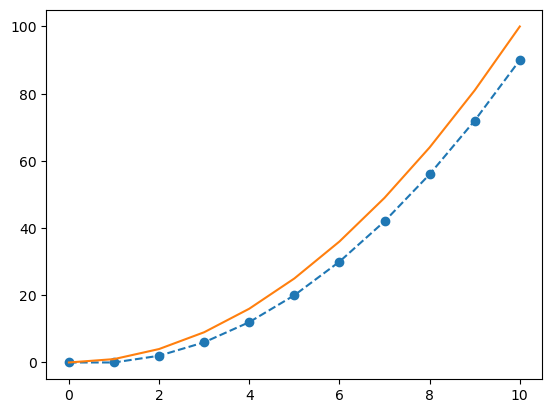

In [30]:
f1 = lambda x,y: 2*x + 0*y
y0 = 0

y10, x10 = Euler_explicito(odefun=f1, t_span=(0.0, 10.0), y0=0.0, hfix=1.0, return_trajectory=True)
yexact = lambda x: x**2
plt.plot(x10,y10,'--o')
plt.plot(x10,yexact(np.asarray(x10)))
plt.show()

## Ejemplo:
\begin{equation}
y' = \tan^{-1}(y),\quad y(0) = y_0 
\end{equation}

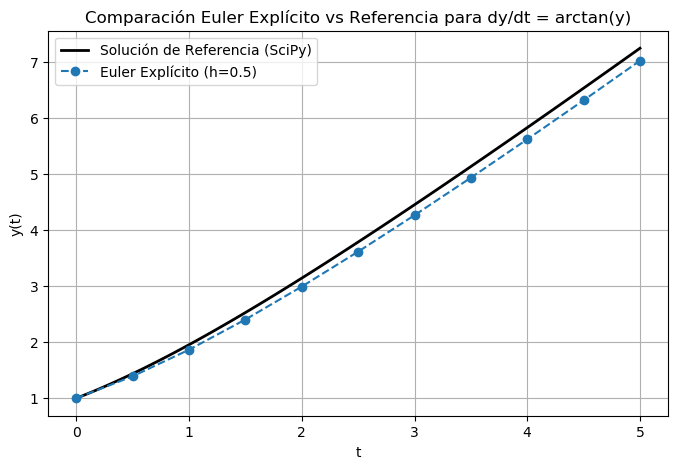

In [38]:
from scipy.integrate import solve_ivp
f1 = lambda x, y: np.arctan(y)
y0 = 1.0

# y10, x10 = Euler_explicito(f1, y0, 10, 5, 0)
t_span =(0.0, 5.0)
y10, x10 = Euler_explicito(odefun=f1, t_span=t_span, y0=y0, hfix=.5, return_trajectory=True)
y0 = [1.0]
sol_ref = solve_ivp(f1, t_span, y0, t_eval=np.linspace(t_span[0], t_span[1], 100))

# 4. Graficar comparación
plt.figure(figsize=(8, 5))
plt.plot(sol_ref.t, sol_ref.y[0], 'k-', label='Solución de Referencia (SciPy)', linewidth=2)
plt.plot(x10, y10, '--o', label='Euler Explícito (h=0.5)')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Comparación Euler Explícito vs Referencia para dy/dt = arctan(y)')
plt.legend()
plt.grid(True)
plt.show()

## Ejemplo 2:
\begin{equation}
y' = y^{2} - \frac{x^{4} - 6x^{3} + 12x^{2} - 14x + 9}{(1+x)^{2}},\quad y(0) = 2 
\end{equation}

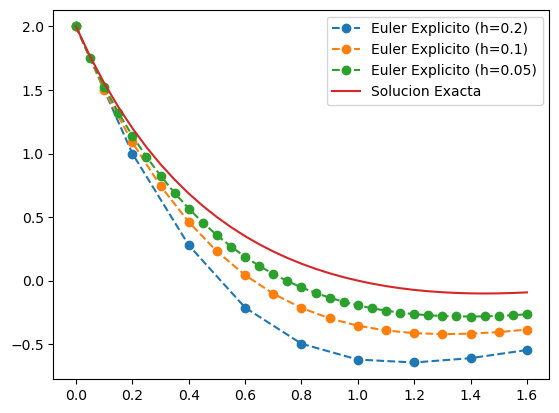

In [42]:
f2 = lambda x, y: y**2-(x**4-6*x**3 + 12*x**2 - 14*x + 9)/(1+x)**2
y0 = 2
yexact = lambda x: (1-x)*(2-x)/(1+x)
XM=1.6
y8, x8 = Euler_explicito(odefun=f2, t_span=(0.0, XM), y0=y0, hfix=XM/8.0, return_trajectory=True)
y16, x16 = Euler_explicito(odefun=f2, t_span=(0.0, XM), y0=y0, hfix=XM/16.0, return_trajectory=True)
y32, x32 = Euler_explicito(odefun=f2, t_span=(0.0, XM), y0=y0, hfix=XM/32.0, return_trajectory=True)

plt.plot(x8,y8, '--o', label='Euler Explicito (h=0.2)')
plt.plot(x16,y16, '--o', label='Euler Explicito (h=0.1)')
plt.plot(x32,y32, '--o', label='Euler Explicito (h=0.05)')
plt.plot(x32, yexact(np.asarray(x32)), label='Solucion Exacta')
plt.legend()
plt.show()

<hr style="border:3px solid #E3AE00 "> </hr>


---
## Metodo de Euler implicito

In [43]:
from scipy.optimize import newton
def Euler_implicito(odefun, t_span, y0, hfix, return_trajectory=False, odefunprime=None):
    '''
    Método de Euler implícito para resolver PVI: dy/dt = odefun(t, y), y(t0) = y0
    Inputs: - odefun : callable. Función que define la EDO f(t, y).
            - t_span : tuple. Intervalo de integración (t0, tf).
            - y0     : float o np.ndarray. Condición inicial.
            - hfix   : float. Tamaño de paso temporal fijo base. 
            - return_trajectory : bool, opcional. Si es True, retorna la trayectoria completa (t, y). 
                                  Si es False, retorna solo el valor final (y_final, t_final).
            - odefunprime : callable, opcional. Jacobiano df/dy de la EDO.
    Output: - Si return_trajectory=True:  (t_array, y_array)
            - Si return_trajectory=False: (y_final, t_final)
    '''
    t0, tf = t_span
    t = t0
    y = np.array(y0, dtype=float) if isinstance(y0, (list, np.ndarray)) else float(y0)
    
    # Definir identidad según sea escalar o vector para el cálculo del Jacobiano
    if np.isscalar(y): 
        I = 1.0 
    else: 
        I = np.eye(y.size)
        
    if return_trajectory:
        tn = [t0]
        yh = [y.copy() if isinstance(y, np.ndarray) else y]
        
        while tf - t > 1e-14:
            h = min(hfix, tf - t)
            
            # Función no lineal F(z) = 0 a resolver en cada paso t + h
            F = lambda z: z - h * odefun(t + h, z) - y
            J = (lambda z: I - h * odefunprime(t + h, z)) if odefunprime is not None else None
            
            # Resolución con Newton usando el valor actual 'y' como estimación inicial
            y = newton(F, y, fprime=J)
            t += h
            
            tn.append(t)
            yh.append(y.copy() if isinstance(y, np.ndarray) else y)
            
        return np.array(yh), np.array(tn)
    else:
        while tf - t > 1e-14:
            h = min(hfix, tf - t)
            
            F = lambda z: z - h * odefun(t + h, z) - y
            J = (lambda z: I - h * odefunprime(t + h, z)) if odefunprime is not None else None
            
            y = newton(F, y, fprime=J)
            t += h
            
        return y, t

## Ejemplo.
Comparamos los metodos de Euler explicito y Euler implicito para el siguiente PVI
$$
y' = -y^{2}, \quad y(0) = 1
$$


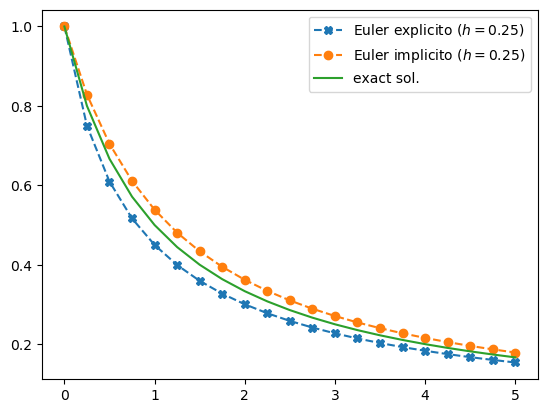

In [46]:
fun = lambda x,y : -y**2
dfundy = lambda x,y: -2*y
yexact = lambda x: 1.0/(1.0+x)

ye,te = Euler_explicito(odefun=fun, t_span=(0.0, 5.0), y0=1.0, hfix=5.0/20.0, return_trajectory=True)
y,t = Euler_implicito(odefun=fun, t_span=(0.0,5.0), y0=1.0, hfix=5.0/20.0, return_trajectory=True, odefunprime=dfundy)
#y,t = Euler_implicito(odefun=fun, t_span=(0.0,5.0), y0=1.0, h=5.0/20.0, return_trajectory=True)

plt.plot(te,ye, '--X', label='Euler explicito ($h=0.25$)')
plt.plot(t,y, '--o', label='Euler implicito ($h=0.25$)')
plt.plot(t, yexact(t), label='exact sol.')
plt.legend()
plt.show()

---
## Regla trapezoidal

In [57]:
import numpy as np
from scipy.optimize import newton

def trapezoidalrule(odefun, t_span, y0, hfix, return_trajectory=False, odefunprime=None):
    '''
    Método de la Regla del Trapecio para resolver PVI: dy/dt = odefun(t, y), y(t0) = y0
    Inputs: - odefun : callable. Función que define la EDO f(t, y).
            - t_span : tuple. Intervalo de integración (t0, tf).
            - y0     : float o np.ndarray. Condición inicial.
            - hfix   : float. Tamaño de paso temporal fijo base.
            - return_trajectory : bool, opcional. Si es True, retorna la trayectoria completa (t, y). 
                                  Si es False, retorna solo el valor final (y_final, t_final).
            - odefunprime : callable, opcional. Jacobiano df/dy de la EDO.
    Output: - Si return_trajectory=True:  (t_array, y_array)
            - Si return_trajectory=False: (y_final, t_final)
    '''
    t0, tf = t_span
    t = t0
    y = np.array(y0, dtype=float) if isinstance(y0, (list, np.ndarray)) else float(y0)
    
    # Definir identidad según sea escalar o vector para el cálculo del Jacobiano
    if np.isscalar(y): 
        I = 1.0 
    else: 
        I = np.eye(y.size)
        
    if return_trajectory:
        tn = [t0]
        yh = [y.copy() if isinstance(y, np.ndarray) else y]
        while tf - t > 1e-14:
            h = min(hfix, tf - t)
            f_n = odefun(t, y)
            F = lambda z: z - y - 0.5 * h * (f_n + odefun(t + h, z))
            # J = I - 0.5 * h * f'(t_{n+1}, z)
            J = (lambda z: I - 0.5 * h * odefunprime(t + h, z)) if odefunprime is not None else None
            y = newton(F, y, fprime=J)
            t += h
            tn.append(t)
            yh.append(y.copy() if isinstance(y, np.ndarray) else y)
        return  np.array(yh), np.array(tn)
    else:
        while tf - t > 1e-14:
            h = min(hfix, tf - t)
            f_n = odefun(t, y)
            F = lambda z: z - y - 0.5 * h * (f_n + odefun(t + h, z))
            J = (lambda z: I - 0.5 * h * odefunprime(t + h, z)) if odefunprime is not None else None
            y = newton(F, y, fprime=J)
            t += h
        return y, t

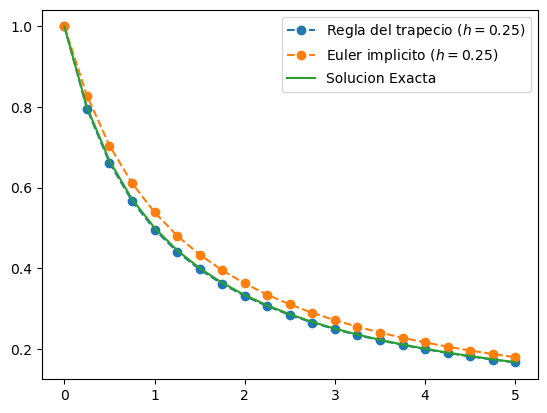

In [61]:
fun = lambda x,y : -y**2
dfundy = lambda x,y: -2*y
yexact = lambda x: 1.0/(1.0+x)

yEI,tEI = Euler_implicito(odefun=fun, t_span=(0.0,5.0), y0=1.0, hfix=5.0/20.0, return_trajectory=True, odefunprime=dfundy)
y,t = trapezoidalrule(odefun=fun, t_span=(0.0,5.0), y0=1.0, hfix=5.0/20.0, return_trajectory=True)

plt.plot(t,y, '--o', label='Regla del trapecio ($h=0.25$)')
plt.plot(tEI,yEI, '--o', label='Euler implicito ($h=0.25$)')
plt.plot(t, yexact(t), label='Solucion Exacta')
plt.legend()
plt.show()

---
## Ejemplo: Cuando todo va bien
\begin{alignat}{4}
y' &= - y + 2\exp(-x)\cos(2x) \\
y(0)& = 0 \\
h & = \frac{1}{2}, \frac{1}{10}, \frac{1}{50}.
\end{alignat}

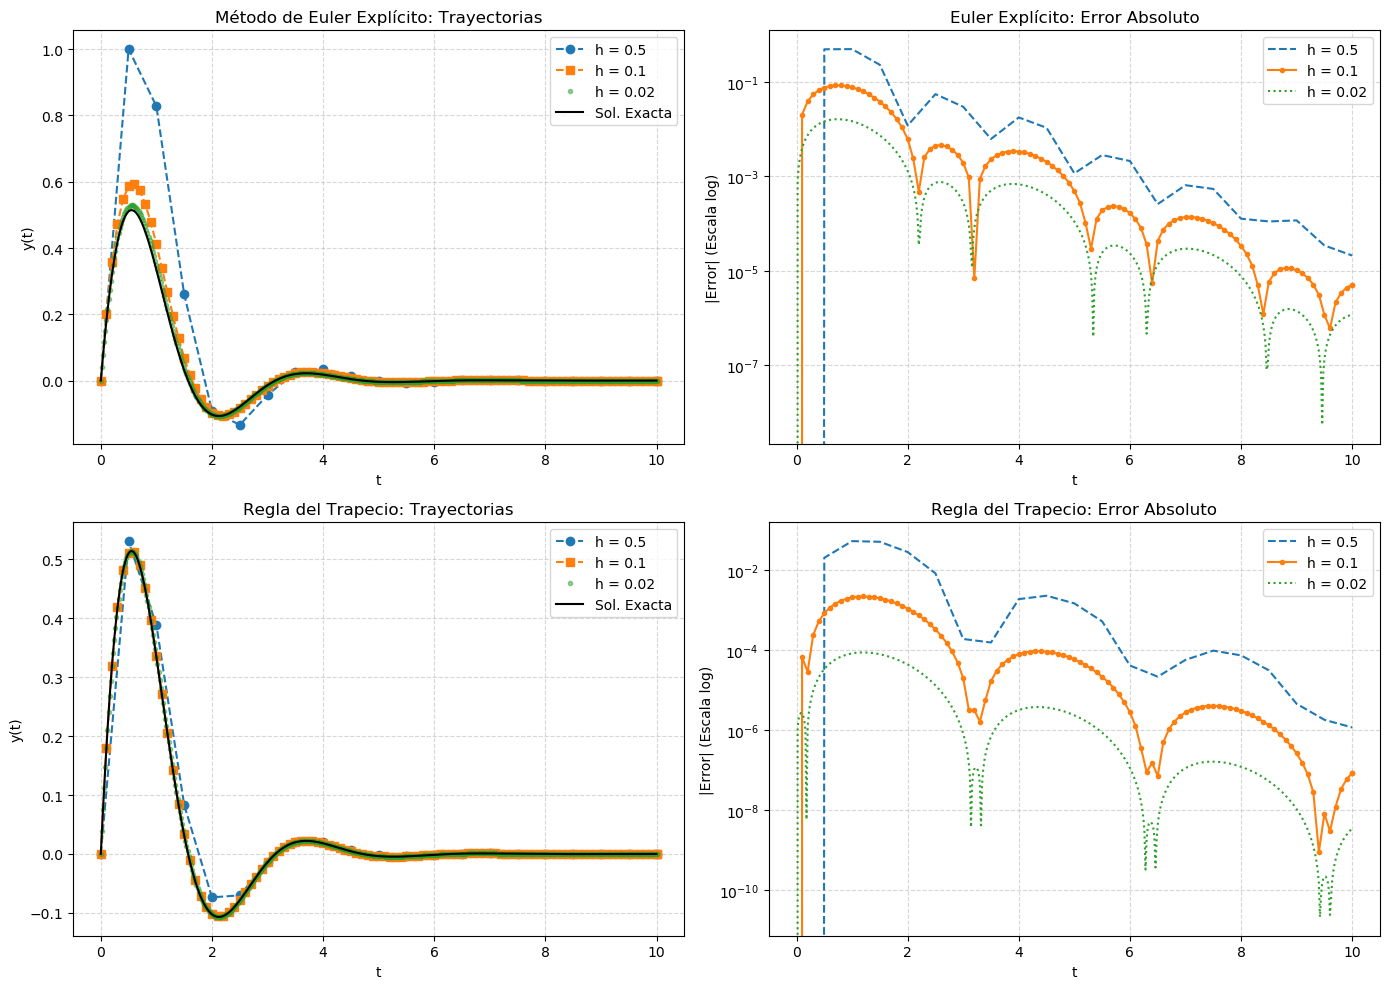

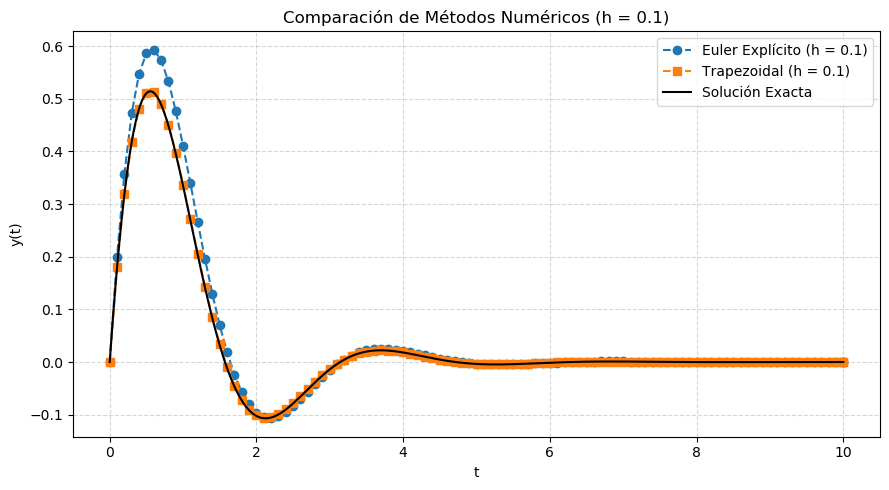

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# --- Definición del problema ---
f3 = lambda x, y: -y + 2 * np.exp(-x) * np.cos(2 * x)
f3prime = lambda x, y: -1 + 0 * y + 0 * x  # df/dy
y0 = 0
XM = 10
h = np.array([0.5, 0.1, 0.02])
N = [int(XM / hi) for hi in h]
yexact = lambda x: np.exp(-x) * np.sin(2 * x)

# --- Simulaciones Euler Explicito ---
y1, x1 = Euler_explicito(odefun=f3, t_span=(0.0, XM), y0=y0, hfix=h[0], return_trajectory=True)
y2, x2 = Euler_explicito(odefun=f3, t_span=(0.0, XM), y0=y0, hfix=h[1], return_trajectory=True)
y3, x3 = Euler_explicito(odefun=f3, t_span=(0.0, XM), y0=y0, hfix=h[2], return_trajectory=True)

# --- Simulaciones Regla del Trapecio ---
Th1, xh1 = trapezoidalrule(odefun=f3, t_span=(0.0, XM), y0=y0, hfix=h[0], return_trajectory=True, odefunprime=f3prime)
Th2, xh2 = trapezoidalrule(odefun=f3, t_span=(0.0, XM), y0=y0, hfix=h[1], return_trajectory=True, odefunprime=f3prime)
Th3, xh3 = trapezoidalrule(odefun=f3, t_span=(0.0, XM), y0=y0, hfix=h[2], return_trajectory=True, odefunprime=f3prime)


# =========================================================================
# FIGURA 1: Panel Organizado (2x2) para Euler y Trapecial
# =========================================================================
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# --- 1. Subplot Superior Izquierdo: Trayectorias Euler ---
axs[0, 0].plot(x1, y1, 'o--', label='h = 0.5')
axs[0, 0].plot(x2, y2, 's--', label='h = 0.1')
axs[0, 0].plot(x3, y3, '.', label='h = 0.02', alpha=0.5)
axs[0, 0].plot(x3, yexact(np.asarray(x3)), 'k-', label='Sol. Exacta', linewidth=1.5)
axs[0, 0].set_title('Método de Euler Explícito: Trayectorias')
axs[0, 0].set_xlabel('t')
axs[0, 0].set_ylabel('y(t)')
axs[0, 0].grid(True, linestyle='--', alpha=0.5)
axs[0, 0].legend()

# --- 2. Subplot Superior Derecho: Errores Euler (Semilogy) ---
eh1 = np.abs(yexact(np.asarray(x1)) - y1)
eh2 = np.abs(yexact(np.asarray(x2)) - y2)
eh3 = np.abs(yexact(np.asarray(x3)) - y3)
axs[0, 1].semilogy(x1, eh1, '--', label='h = 0.5')
axs[0, 1].semilogy(x2, eh2, '.-', label='h = 0.1')
axs[0, 1].semilogy(x3, eh3, ':', label='h = 0.02')
axs[0, 1].set_title('Euler Explícito: Error Absoluto')
axs[0, 1].set_xlabel('t')
axs[0, 1].set_ylabel('|Error| (Escala log)')
axs[0, 1].grid(True, linestyle='--', alpha=0.5)
axs[0, 1].legend()

# --- 3. Subplot Inferior Izquierdo: Trayectorias Trapecial ---
axs[1, 0].plot(xh1, Th1, 'o--', label='h = 0.5')
axs[1, 0].plot(xh2, Th2, 's--', label='h = 0.1')
axs[1, 0].plot(xh3, Th3, '.', label='h = 0.02', alpha=0.5)
axs[1, 0].plot(xh3, yexact(np.asarray(xh3)), 'k-', label='Sol. Exacta', linewidth=1.5)
axs[1, 0].set_title('Regla del Trapecio: Trayectorias')
axs[1, 0].set_xlabel('t')
axs[1, 0].set_ylabel('y(t)')
axs[1, 0].grid(True, linestyle='--', alpha=0.5)
axs[1, 0].legend()

# --- 4. Subplot Inferior Derecho: Errores Trapecial (Semilogy) ---
eh1T = np.abs(yexact(np.asarray(xh1)) - Th1)
eh2T = np.abs(yexact(np.asarray(xh2)) - Th2)
eh3T = np.abs(yexact(np.asarray(xh3)) - Th3)
axs[1, 1].semilogy(xh1, eh1T, '--', label='h = 0.5')
axs[1, 1].semilogy(xh2, eh2T, '.-', label='h = 0.1')
axs[1, 1].semilogy(xh3, eh3T, ':', label='h = 0.02')
axs[1, 1].set_title('Regla del Trapecio: Error Absoluto')
axs[1, 1].set_xlabel('t')
axs[1, 1].set_ylabel('|Error| (Escala log)')
axs[1, 1].grid(True, linestyle='--', alpha=0.5)
axs[1, 1].legend()

plt.tight_layout()
plt.savefig('panel_euler_trapecio.png', dpi=300)
plt.show()


# =========================================================================
# FIGURA 2: Comparación directa entre Euler y Trapecio (para h = 0.1)
# =========================================================================
fig_comp, ax_comp = plt.subplots(figsize=(9, 5))
ax_comp.plot(x2, y2, 'o--', label='Euler Explícito (h = 0.1)')
ax_comp.plot(xh2, Th2, 's--', label='Trapezoidal (h = 0.1)')
ax_comp.plot(x3, yexact(np.asarray(x3)), 'k-', label='Solución Exacta', linewidth=1.5)
ax_comp.set_title('Comparación de Métodos Numéricos (h = 0.1)')
ax_comp.set_xlabel('t')
ax_comp.set_ylabel('y(t)')
ax_comp.grid(True, linestyle='--', alpha=0.5)
ax_comp.legend()

plt.tight_layout()
plt.savefig('figclase3.png', dpi=300)
plt.show()

In [69]:
import pandas as pd
# =========================================================================
# ANÁLISIS DE CONVERGENCIA Y ORDEN ESTIMADO (EOC)
# =========================================================================
def eoc(h, error): # estimated rates of convergence
    r = [0.0]
    for j in range(1, h.size):
        r.append(np.log(error[j]/error[j-1]) / np.log(h[j]/h[j-1]))
    return np.asarray(r)

# Cálculo de los errores máximos para cada método y tamaño de paso h
maxErrorEuler = [np.max(err) for err in [eh1, eh2, eh3]]
maxErrorTrap  = [np.max(err) for err in [eh1T, eh2T, eh3T]]

# Construcción de la tabla resumen en Pandas
dictex1 = {
    "h": h, 
    "Error Euler": maxErrorEuler, 
    "eoc Euler": eoc(h, maxErrorEuler), 
    "Error Trap.": maxErrorTrap,
    "eoc Trap.": eoc(h, maxErrorTrap)
}
dfex1 = pd.DataFrame(dictex1)

# Mostrar la tabla de convergencia en consola
print("Tabla de Convergencia y Órdenes (EOC):")
dfex1



Tabla de Convergencia y Órdenes (EOC):


,h,Error Euler,eoc Euler,Error Trap.,eoc Trap.
0,0.50,0.493198,0.000000,0.053986,0.000000
1,0.10,0.084174,1.098535,0.002232,1.979591
2,0.02,0.016176,1.024808,0.000089,2.000709


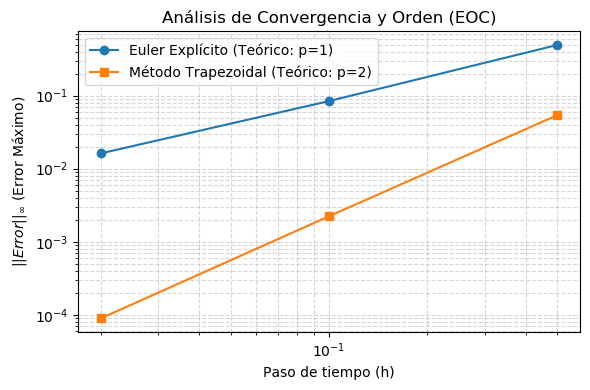

In [71]:
# =========================================================================
# GRÁFICO DE CONVERGENCIA EN ESCALA LOG-LOG
# =========================================================================
plt.figure(figsize=(6, 4))
plt.loglog(h, maxErrorEuler, 'o-', label='Euler Explícito (Teórico: p=1)')
plt.loglog(h, maxErrorTrap,  's-', label='Método Trapezoidal (Teórico: p=2)')

plt.xlabel('Paso de tiempo (h)')
plt.ylabel(r'$||Error||_{\infty}$ (Error Máximo)')
plt.title('Análisis de Convergencia y Orden (EOC)')
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

# Opcional: guardar la figura para incluirla en las transparencias (Beamer)
plt.savefig('convergencia_clase3.png', dpi=300)
plt.show()

Con la solucion exacta podemos calcular una aproximacion de los ordenes de convergencia de forma experimental. Esto lo hacemos de la siguiente forma
$$
r_{h'} = \log(e_{h'}/e_{h})/\log(h'/h)
$$
En este caso el error parece oscilar en tiempo, lo que puede explicarse por la componente periodica de la solucion exacta. Ademas se observa para ambos metodos que el error parece decaer en tiempo. Podriamos pensar que el error tenderia a acumularse de un paso al siguiente, sin embargo, como se ve en este ejemplo, esto no es necesariamente correcto.

--- 
## Ejemplo: Cuando falla
\begin{alignat}{4}
y' &= \log(3)(y - [y]-3/2) \\
y(0)& = 0 \\
h & = \frac{1}{100}, \frac{1}{1000}.
\end{alignat}

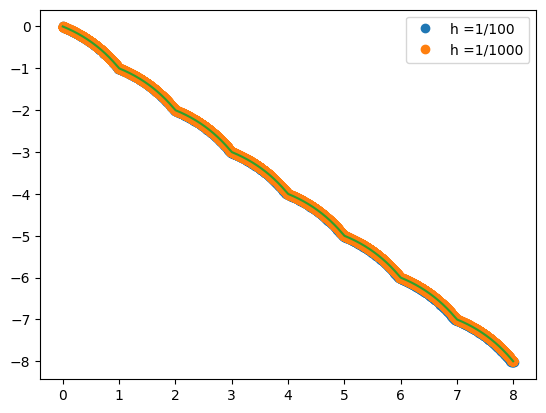

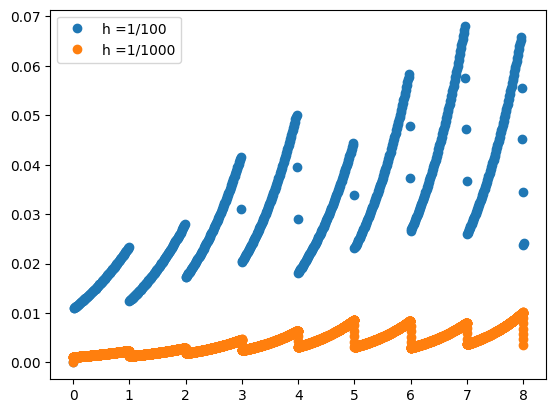

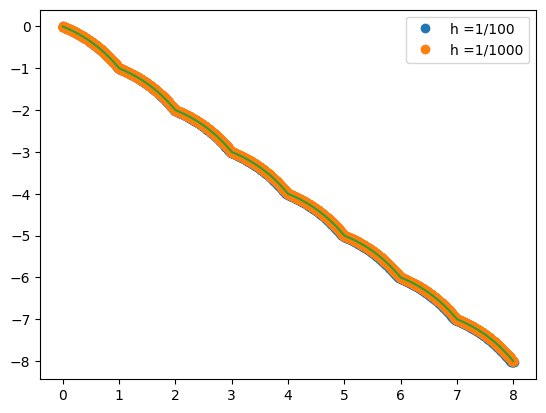

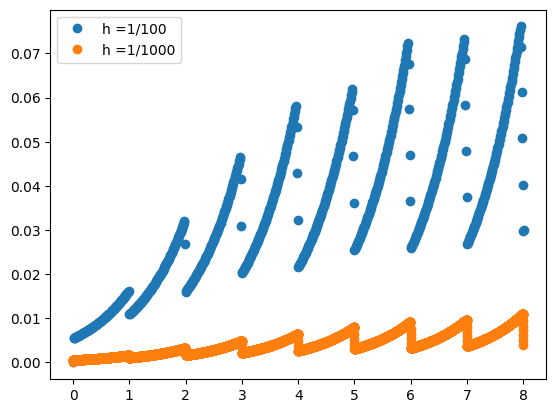

In [44]:
f4 = lambda x, y: np.log(3)*(y-np.floor(y)-1.5 )

y0 = 0
XM = 8
h = np.array([0.01,0.001])
N = [int(XM/hi) for hi in h]

yexact = lambda x: -np.floor(x) + 0.5*(1-3**(x-np.floor(x)))
# Euler
yh1, xh1 = Euler_explicito(odefun=f4, t_span=(0.0, XM), y0=y0, h=h[0], return_trajectory=True)
yh2, xh2 = Euler_explicito(odefun=f4, t_span=(0.0, XM), y0=y0, h=h[1], return_trajectory=True)

plt.plot(xh1,yh1, 'o', label='h =1/100')
plt.plot(xh2,yh2, 'o', label='h =1/1000')
plt.plot(xh2, yexact(np.asarray(xh2)))
plt.legend()
plt.show()

fig, ax = plt.subplots(1)
eh1 = np.abs(yexact(np.asarray(xh1))-yh1)
eh2 = np.abs(yexact(np.asarray(xh2))-yh2)
ax.plot(xh1,eh1, 'o', label='h =1/100')
ax.plot(xh2,eh2, 'o', label='h =1/1000')
ax.legend()
plt.show()

# Trapezoidal
Th1, xh1 = trapezoidalrule(odefun=f4, t_span=(0.0,XM), y0=0, h=h[0], return_trajectory=True, odefunprime=f3 )
Th2, xh2 = trapezoidalrule(odefun=f4, t_span=(0.0,XM), y0=0, h=h[1], return_trajectory=True, odefunprime=f3 )


plt.plot(xh1,Th1, 'o', label='h =1/100')
plt.plot(xh2,Th2, 'o', label='h =1/1000')
plt.plot(xh2, yexact(np.asarray(xh2)))
plt.legend()
plt.show()

fig, ax = plt.subplots(1)
eh1T = np.abs(yexact(np.asarray(xh1))-Th1)
eh2T = np.abs(yexact(np.asarray(xh2))-Th2)
ax.plot(xh1,eh1T, 'o', label='h =1/100')
ax.plot(xh2,eh2T, 'o', label='h =1/1000')
ax.legend()
plt.show()

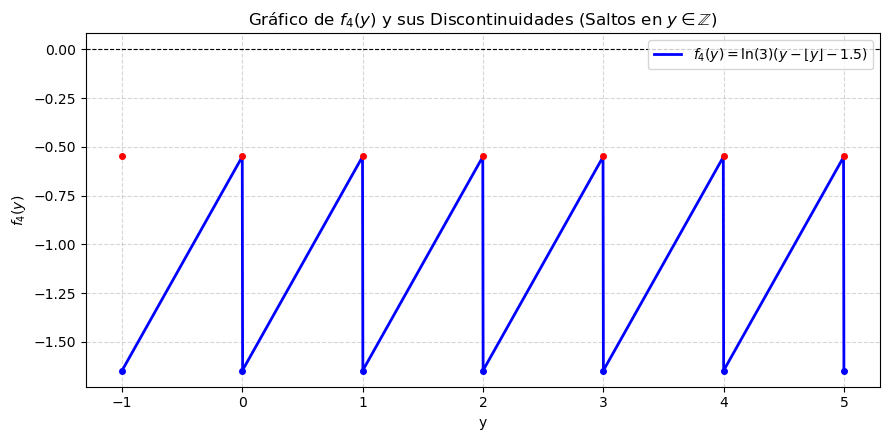

In [75]:
f4_y = lambda y: np.log(3) * (y - np.floor(y) - 1.5)

# Generamos valores de y para visualizar varios periodos de la discontinuidad
y_vals = np.linspace(-1, 5, 2000)
f_vals = f4_y(y_vals)

plt.figure(figsize=(9, 4.5))
plt.plot(y_vals, f_vals, 'b-', linewidth=2, label='$f_4(y) = \\ln(3)(y - \\lfloor y \\rfloor - 1.5)$')

# Marcamos los puntos de salto (enteros) para evidenciar las discontinuidades
enteros = np.arange(-1, 6)
for n in enteros:
    # Mostramos el límite por la izquierda y por la derecha en los saltos
    plt.plot(n, f4_y(n - 1e-5), 'ro', markersize=4) # Valor antes del salto
    plt.plot(n, f4_y(n + 1e-5), 'bo', markersize=4) # Valor después del salto

plt.title('Gráfico de $f_4(y)$ y sus Discontinuidades (Saltos en $y \in \mathbb{Z}$)')
plt.xlabel('y')
plt.ylabel('$f_4(y)$')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

yexact = lambda x: -np.floor(x) + 0.5*(1-3**(x-np.floor(x)))

In [46]:
maxErrorEuler = [ np.max(err) for err in [eh1, eh2]]
maxErrorTrap  = [ np.max(err) for err in [eh1T, eh2T]]
              
dictex2 = {"h": h , "Error Euler":maxErrorEuler, "eoc Euler": eoc(h, maxErrorEuler), "Error Trap":maxErrorTrap,"eoc Trap.":eoc(h, maxErrorTrap)}
dfex2 = pd.DataFrame(dictex2)
dfex2

,h,Error Euler,eoc Euler,Error Trap,eoc Trap.
0,0.010,0.067978,0.000000,0.076092,0.00000
1,0.001,0.010133,0.826628,0.011080,0.83679


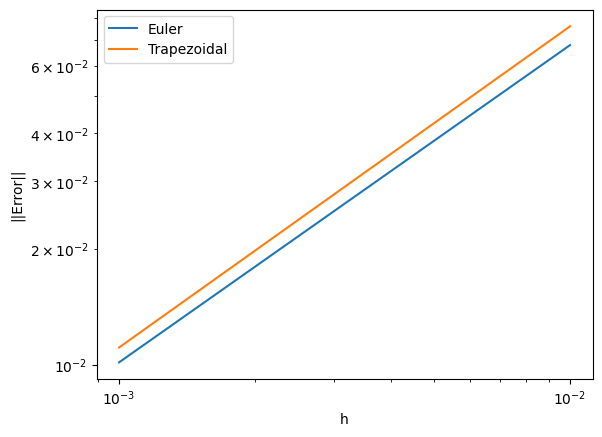

In [47]:
# Graficos de error
plt.loglog(h, maxErrorEuler,label='Euler')
plt.loglog(h, maxErrorTrap,label='Trapezoidal')
plt.legend()
plt.xlabel('h')
plt.ylabel('||Error||')
plt.show()

Los Teoremas vistos en clases asumen que $f$ satisface la condicion de Lipschitz. Por esta razon, esperariamos con los metodos numericos, aun aplicables a casos sin esta condicion, no nos entreguen el rendimiento esperado. En este ejemplo la funcion $f$ no satisface esta condicion (demuestrelo).

Se observa experimentalmente que el error decrece con $h$, a razon $\mathcal O(h)$ para ambos m\'etodos. En particular para la regla trapezoidal esto no es lo que se espera en el caso Lipschitz.

## Clase 4

## Ejemplo: Convergencia
\begin{equation}
y' = -y^{2},\qquad y(0) = 1
\end{equation}

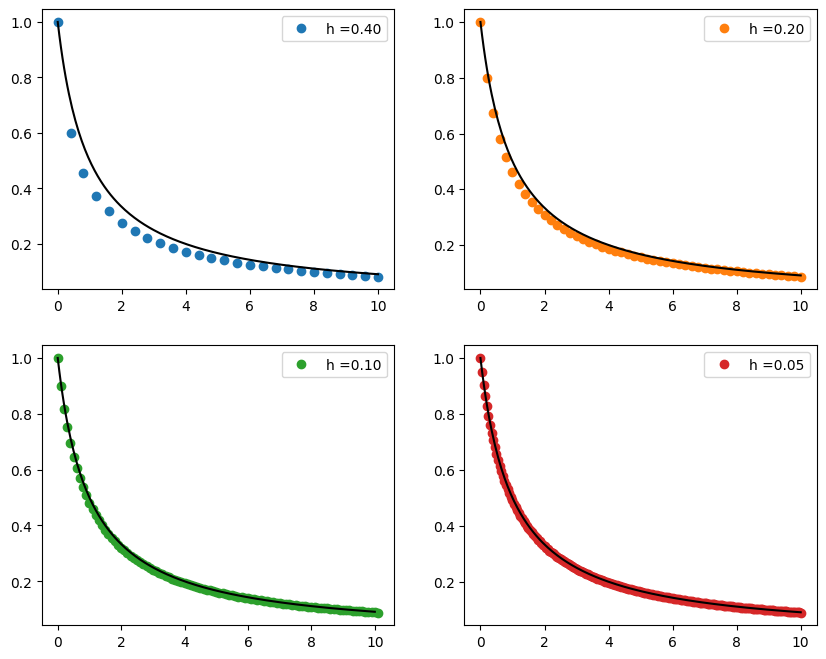

In [2]:
from Capitulo1_metodos import Euler_explicito, trapezoidalrule
fun = lambda x,y : -y**2
dfundy = lambda x,y: -2*y
y0 = 1
XM = 10
h = [0.4, 0.2, 0.1, 0.05, 0.025, 0.0125]
N = [int(XM/hi) for hi in h]

yexact = lambda x: 1.0/(1.0+x)
YH = []
XH = []
# Euler
for i,hi in enumerate(h):
#     yh, xh = Euler_explicito(fun, y0, N=N[i], XM = XM, x0 =0)
#     Euler_explicito(odefun=fun, t_span=, y0, h=None, return_trajectory=False)
    yh, xh = Euler_explicito(odefun=fun, t_span=(0.0, XM), y0=y0, h=h[i], return_trajectory=True)
    YH.append(yh)
    XH.append(xh)

fig, ax = plt.subplots(2,2, figsize=(10,8))
ax[0,0].plot(XH[0],YH[0], 'o', color='C00',label='h =%.2f'%h[0])
ax[0,0].plot(XH[3], yexact(np.asarray(XH[3])),'k')
ax[0,0].legend()
ax[0,1].plot(XH[1],YH[1], 'o', color='C01',label='h =%.2f'%h[1])
ax[0,1].plot(XH[3], yexact(np.asarray(XH[3])),'k')
ax[0,1].legend()
ax[1,0].plot(XH[2],YH[2], 'o', color='C02',label='h =%.2f'%h[2])
ax[1,0].plot(XH[3], yexact(np.asarray(XH[3])),'k')
ax[1,0].legend()
ax[1,1].plot(XH[3],YH[3], 'o', color='C03',label='h =%.2f'%h[3])
ax[1,1].plot(XH[3], yexact(np.asarray(XH[3])),'k')
ax[1,1].legend()
plt.show()

## Compute error 
EH = []
EOC = ['-']
for i,hi in enumerate(h):
    eh = np.max(np.abs(yexact(np.asarray(XH[i]))-YH[i]))
    EH.append(eh)
    if i>0:
        EOC.append(np.log(EH[i]/EH[i-1])/np.log(h[i]/h[i-1]))
        
        
# Trapezoidal rule
TH = []
XH = []
for i,hi in enumerate(h):
#     th, xh = trapezoidalrule(fun, y0, N=N[i], XM = XM, x0 =0, dfdy=dfundy)
    th,xh = trapezoidalrule(odefun=fun, t_span=(0.0,XM), y0=y0, h=hi, return_trajectory=True, odefunprime=dfundy)
    TH.append(th)
    XH.append(xh)
## Compute error 
EHT = []
EOCT = ['-']
for i,hi in enumerate(h):
    eh = np.max(np.abs(yexact(np.asarray(XH[i]))-TH[i]))
    EHT.append(eh)
    if i>0:
        EOCT.append(np.log(EHT[i]/EHT[i-1])/np.log(h[i]/h[i-1]))

In [3]:
df = pd.DataFrame({'h':h, 'Euler error':EH, 'Euler eoc':EOC,  'Trap. error':EHT, 'Trap. eoc':EOCT})
df

,h,Euler error,Euler eoc,Trap. error,Trap. eoc
0,0.4000,0.114286,-,0.012724,-
1,0.2000,0.043317,1.399647,0.002979,2.094603
2,0.1000,0.019836,1.126826,0.000744,2.001097
3,0.0500,0.009532,1.057308,0.000185,2.005023
4,0.0250,0.004680,1.026125,0.000046,2.001253
5,0.0125,0.002319,1.012787,0.000012,2.000313


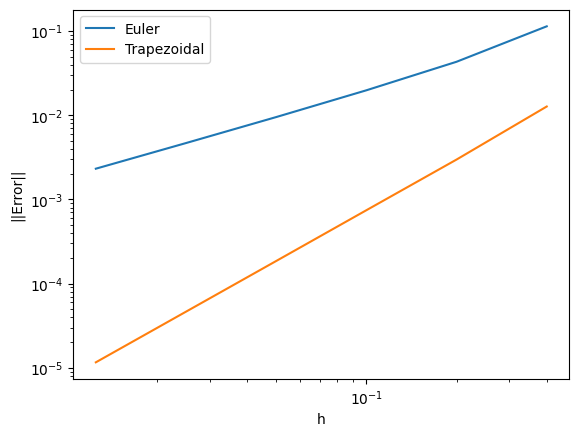

In [4]:
# Graficos de error
plt.loglog(h, EH,label='Euler')
plt.loglog(h, EHT,label='Trapezoidal')
plt.legend()
plt.xlabel('h')
plt.ylabel('||Error||')
plt.show()

---
## Metodos de paso multiple

In [3]:
from Capitulo1_metodos import simpsonmult

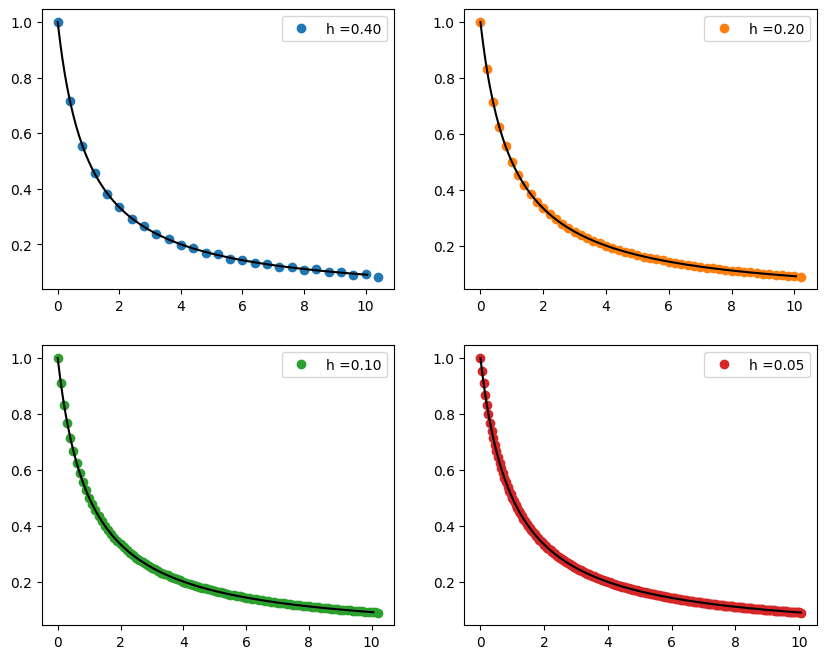

,h,Simpson error,Simpson eoc
0,0.4000,3.675697e-03,-
1,0.2000,2.466939e-04,3.897224
2,0.1000,1.171779e-05,4.39595
3,0.0500,5.108886e-07,4.519548
4,0.0250,3.029583e-08,4.075818
5,0.0125,1.833675e-09,4.046309


In [4]:
fun = lambda x,y : -y**2
dfundy = lambda x,y: -2*y
y0 = 1.0
XM = 10
h = [0.4, 0.2, 0.1, 0.05, 0.025, 0.0125]
N = [int(XM/hi) for hi in h]

yexact = lambda x: 1.0/(1.0+x)

YH = []
XH = []
# Simpson rule paso multiple

for i,hi in enumerate(h):
    y1 = 1.0/(1.0+hi)
    yh, xh = simpsonmult(fun, t_span=(0,XM), y0=y0, h =hi, y1=y1, return_trajectory=True, odefunprime=dfundy)
    YH.append(yh)
    XH.append(xh)
# print(YH, XH)
## Compute error 
EH = []
EOC = ['-']
for i,hi in enumerate(h):
    eh = np.max(np.abs(yexact(np.asarray(XH[i]))-YH[i]))
    EH.append(eh)
    if i>0:
        EOC.append(np.log(EH[i]/EH[i-1])/np.log(h[i]/h[i-1]))
        
fig, ax = plt.subplots(2,2, figsize=(10,8))
ax[0,0].plot(XH[0],YH[0], 'o', color='C00',label='h =%.2f'%h[0])
ax[0,0].plot(XH[3], yexact(np.asarray(XH[3])),'k')
ax[0,0].legend()
ax[0,1].plot(XH[1],YH[1], 'o', color='C01',label='h =%.2f'%h[1])
ax[0,1].plot(XH[3], yexact(np.asarray(XH[3])),'k')
ax[0,1].legend()
ax[1,0].plot(XH[2],YH[2], 'o', color='C02',label='h =%.2f'%h[2])
ax[1,0].plot(XH[3], yexact(np.asarray(XH[3])),'k')
ax[1,0].legend()
ax[1,1].plot(XH[3],YH[3], 'o', color='C03',label='h =%.2f'%h[3])
ax[1,1].plot(XH[3], yexact(np.asarray(XH[3])),'k')
ax[1,1].legend()
plt.show()


df = pd.DataFrame({'h':h, 'Simpson error':EH, 'Simpson eoc':EOC})
df

---
## Propiedad Cero Estable 

(o no estables)
### Ejemplo:
\begin{equation}
y_{n+3} + y_{n+2} - y_{n+1} - y_{n} = 2h(f_{n+2}+f_{n+1})
\end{equation}

In [5]:
def methodmulti8(f, y0, y1, y2, N, XM, x0=0):
    h = (XM- x0)/N
    x = []
    x.append(x0); x.append(x0+h); x.append(x0+2*h)
    y = []
    y.append(y0); y.append(y1); y.append(y2)

    xn   = x0; xnp1 = x0+h; xnp2 = x0 +2*h
    yn   = y0; ynp1 = y1; ynp2 = y2
    for n in range(2,N+1):
        xnp3 = xn+3*h
        ynp3 = -ynp2 + ynp1 + yn + 2*h*(f(xn+2*h,ynp2)+f(xn+h, ynp1))
        x.append(xnp3)
        y.append(ynp3)
        yn   = ynp1; xn   = xnp1; 
        ynp1 = ynp2; xnp1 = xnp2;
        ynp2 = ynp3; xnp2 = xnp3;
    return y, x

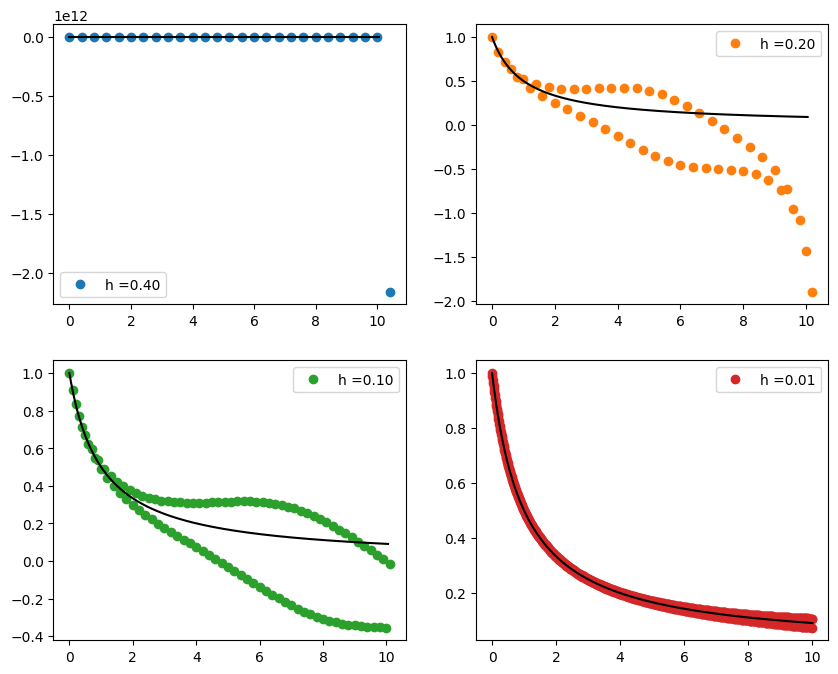

,h,MM8 error,Simpson eoc
0,0.4000,2.156879e+12,-
1,0.2000,1.984081e+00,39.983611
2,0.1000,4.458069e-01,2.15398
3,0.0500,2.306141e-01,0.950938
4,0.0250,6.493557e-02,1.8284
5,0.0125,1.650251e-02,1.976323


In [6]:
YH = []
XH = []
y0 = 1
XM = 10
h = [0.4, 0.2, 0.1, 0.05, 0.025, 0.0125]
N = [int(XM/hi) for hi in h]
for i,hi in enumerate(h):
    y1 = yexact(hi)
    y2 = yexact(2*hi)
    yh, xh = methodmulti8(fun, y0,y1,y2, N=N[i], XM = XM, x0 =0)
    YH.append(yh)
    XH.append(xh)

## Compute error 
EH = []
EOC = ['-']
for i,hi in enumerate(h):
    eh = np.max(np.abs(yexact(np.asarray(XH[i]))-YH[i]))
    EH.append(eh)
    if i>0:
        EOC.append(np.log(EH[i]/EH[i-1])/np.log(h[i]/h[i-1]))
        
fig, ax = plt.subplots(2,2, figsize=(10,8))
ax[0,0].plot(XH[0],YH[0], 'o', color='C00',label='h =%.2f'%h[0])
ax[0,0].plot(XH[3], yexact(np.asarray(XH[3])),'k')
ax[0,0].legend()
ax[0,1].plot(XH[1],YH[1], 'o', color='C01',label='h =%.2f'%h[1])
ax[0,1].plot(XH[3], yexact(np.asarray(XH[3])),'k')
ax[0,1].legend()
ax[1,0].plot(XH[2],YH[2], 'o', color='C02',label='h =%.2f'%h[2])
ax[1,0].plot(XH[3], yexact(np.asarray(XH[3])),'k')
ax[1,0].legend()
ax[1,1].plot(XH[5],YH[5], 'o', color='C03',label='h =%.2f'%h[5])
ax[1,1].plot(XH[5], yexact(np.asarray(XH[5])),'k')
ax[1,1].legend()
plt.show()


df = pd.DataFrame({'h':h, 'MM8 error':EH, 'Simpson eoc':EOC})
df

---
## El metodo explicito mas preciso de 2 pasos

$$
\alpha_{2}y_{n+2} + \alpha_{1} y_{n+1} + \alpha_{0} y_{n} = h(\beta_{1}f_{n+1} + \beta_{0}f_{n})
$$

In [7]:
A = np.array([[1,1,0,0],[0,1,-1,-1],[0,0.5,0,-1],[0,1.0/6.0,0,-0.5]])
b = np.array([-1,-2,-2,-4.0/3.0])
coefficients = np.linalg.solve(A,b)
alpha2 = 1.0
alpha0 = -5.0
alpha1 = 4.0
beta0 = 2.0
beta1 = 4.0
print(coefficients)

[-5.  4.  2.  4.]


In [8]:
def best2stepsmethod(f, y0, y1, N, XM, x0=0 ):
    # Metodo de 2 pasos explicito de orden mas alto
    h = (XM-x0)/N
    yn = y0
    x = []
    x.append(x0); x.append(x0+h)
    y = []
    y.append(y0); y.append(y1)

    xn   = 0; xnp1 = 0 +h
    yn   = y0; ynp1 = y1
    for n in range(2,N+1):
        xnp2 = xn+2*h
        ynp2 = -alpha1*ynp1 - alpha0*yn + h*(beta1*f(xn+h,ynp1)+beta0*f(xn, yn))
        # ynp2 = -4*ynp1 + 5*yn + h*(4*f(xn+h,ynp1)+2*f(xn, yn))
        if np.abs(ynp2)>10**4:
            return y, x
        x.append(xnp2)
        y.append(ynp2)
        
        yn   = ynp1; xn   = xnp1; 
        ynp1 = ynp2; xnp1 = xnp2;
    return y, x

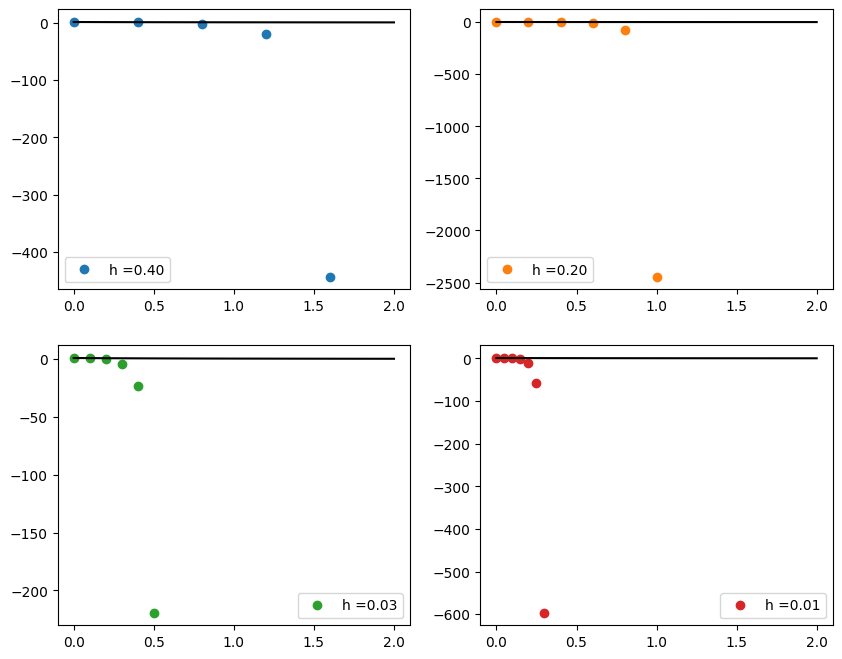

In [11]:
YH = []
XH = []
# Metodo de 2 pasos explicito de orden mas alto
h = [0.4, 0.2, 0.1, 0.05, 0.025, 0.0125]
XM = 2.0
xplot = np.linspace(0,XM,100)
N = [int(XM/hi) for hi in h]
for i,hi in enumerate(h):
    y1 = yexact(hi)
    y2 = yexact(2*hi)
    yh, xh = best2stepsmethod(fun, y0, y1, N=N[i], XM = XM, x0 =0)
    YH.append(yh)
    XH.append(xh)

## Compute error 
EH = []
EOC = ['-']
for i,hi in enumerate(h):
    eh = np.max(np.abs(yexact(np.asarray(XH[i]))-YH[i]))
    EH.append(eh)
    if i>0:
        EOC.append(np.log(EH[i]/EH[i-1])/np.log(h[i]/h[i-1]))
        
fig, ax = plt.subplots(2,2, figsize=(10,8))
ax[0,0].plot(XH[0],YH[0], 'o', color='C00',label='h =%.2f'%h[0])
ax[0,0].plot(xplot, yexact(xplot),'k')
ax[0,0].legend()
ax[0,1].plot(XH[1],YH[1], 'o', color='C01',label='h =%.2f'%h[1])
ax[0,1].plot(xplot, yexact(xplot),'k')
ax[0,1].legend()
ax[1,0].plot(XH[2],YH[2], 'o', color='C02',label='h =%.2f'%h[4])
ax[1,0].plot(xplot, yexact(xplot),'k')
ax[1,0].legend()
ax[1,1].plot(XH[3],YH[3], 'o', color='C03',label='h =%.2f'%h[5])
ax[1,1].plot(xplot, yexact(xplot),'k')
ax[1,1].legend()
plt.show()


## Sistemas de ecuaciones

Capitulo 10. Sistemas de ecuaciones. Exploring ODEs.

1. Considere el sistema de dos variables aut\'onomo

\begin{align*}
\dot{u} & = -v - u(u^{2} + v^{2}) \\
\dot{v} & = u - v(u^{2}+v^{2})
\end{align*}

para $t\in[0,30]$ y con condiciones iniciales $u(0) = 1$ y $v(0) = 0$.

In [15]:
def funsystem1(t,y):
    u,v = y
    F= [-v-u*(u**2+v**2), u - v*(u**2+v**2)]
    return np.asarray(F)

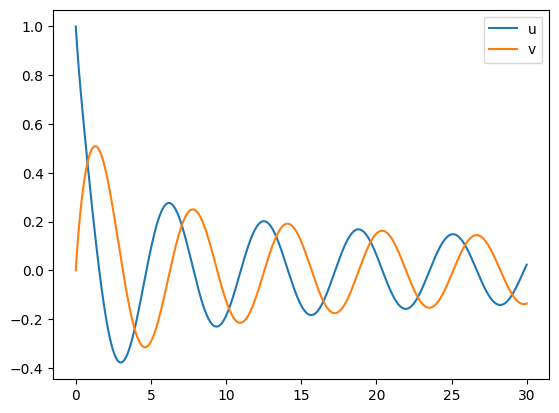

In [50]:
from Capitulo1_metodos import Euler_explicito
u0 = 1.0; v0 = 0.0
y0 = (u0,v0)
# Euler
y1, x1 = Euler_explicito(odefun=funsystem1, t_span=(0.0, 30), y0=y0, h=0.01, return_trajectory=True)
# plots Euler
plt.plot(x1,y1[:,0], '-', label='u')
plt.plot(x1,y1[:,1], '-', label='v')
plt.legend()
plt.show()

**El espacio de fase:**  

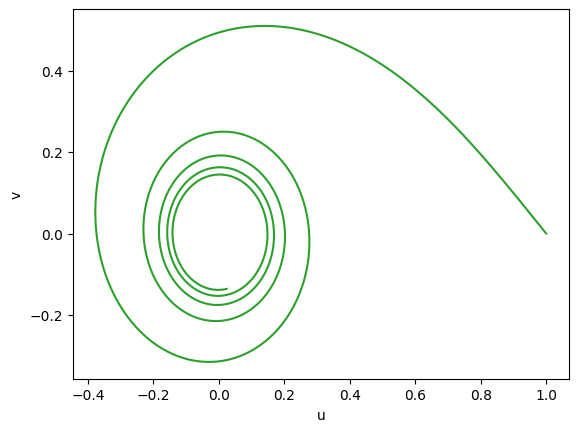

In [52]:
plt.plot(y1[:,0],y1[:,1], '-', color='C02')
plt.xlabel('u')
plt.ylabel('v')
plt.show()

2. **Ecuaciones de Lotka-Volterra**
   
Considere el sistema de dos varaibles conocido como las ecuaciones de depredador-presa o de Lotka-Volterra. Suponemos un ambiente cen el cual hay una especie de presa (conejos), cuya poblacion es una funcion del tiempo $u(t)$ y un especie depredadora (zorros), cuya poblacion es una funcion del tiempo $v(t)$. En la ausencia de zorros, la poblacion de conejos crece exponencialmente gracias a la abundancia de vegetacion, pero esta decrece por encuentros fatales con zorros a una razon proporcional al producto $uv$,

$$
\dot{u} = u - uv.
$$
La poblacion de zorros, por otro lado, decae exponencialmente en la ausencia de conejos pero se expande cuando estos estan disponibles,

$$
\dot{v} = -\frac{1}{5}v + uv 
$$

In [34]:
def funsystem2(t,y):
    u,v = y
    F= [u-u*v,  -0.2*v+ v*u]
    return np.asarray(F)

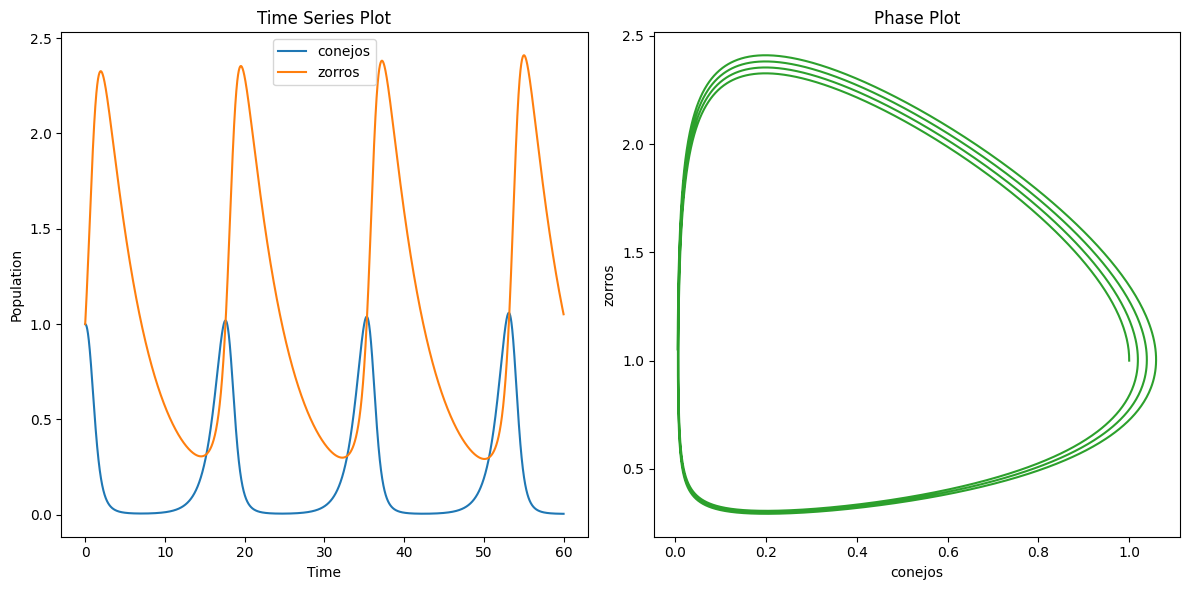

In [49]:
from Capitulo1_metodos import Euler_explicito
u0 = 1.0; v0 = 1.0
y0 = (u0,v0)
# Euler
y2, x2 = Euler_explicito(odefun=funsystem2, t_span=(0.0, 60), y0=y0, h=0.01, return_trajectory=True)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# First subplot (time series)
axs[0].plot(x2, y2[:,0], '-', label='conejos')
axs[0].plot(x2, y2[:,1], '-', label='zorros')
axs[0].legend()
axs[0].set_title('Time Series Plot')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Population')

# Second subplot (phase plot)
axs[1].plot(y2[:,0], y2[:,1], '-', color='C02')
axs[1].set_title('Phase Plot')
axs[1].set_xlabel('conejos')
axs[1].set_ylabel('zorros')

# Show the combined figure
plt.tight_layout()
plt.show()

3. **Ecuaciones de Lorenz**

Las ecuaciones de Lorenz son el arquetipo de un sistema **caotico**. Estas consisten en
\begin{align*}
\dot{u} &= c_1(v-u) \\
\dot{v} & = u(c_2-w) - v \\
\dot{w} & = uv - c_3 w
\end{align*}
con $c_1 =10$, $c_2 = 28$ y $c_3=8/3$, coeficientes arbitrarios (no es necesario usar los mismo valores)

In [2]:
def funsystem3(t,y):
    u,v,w = y
    c1 = 10.0
    c2 = 28.0
    c3 = 8.0/3.0
    F= [c1*(v-u), u*(c2-w)-v, u*v - c3*w]
    return np.asarray(F)

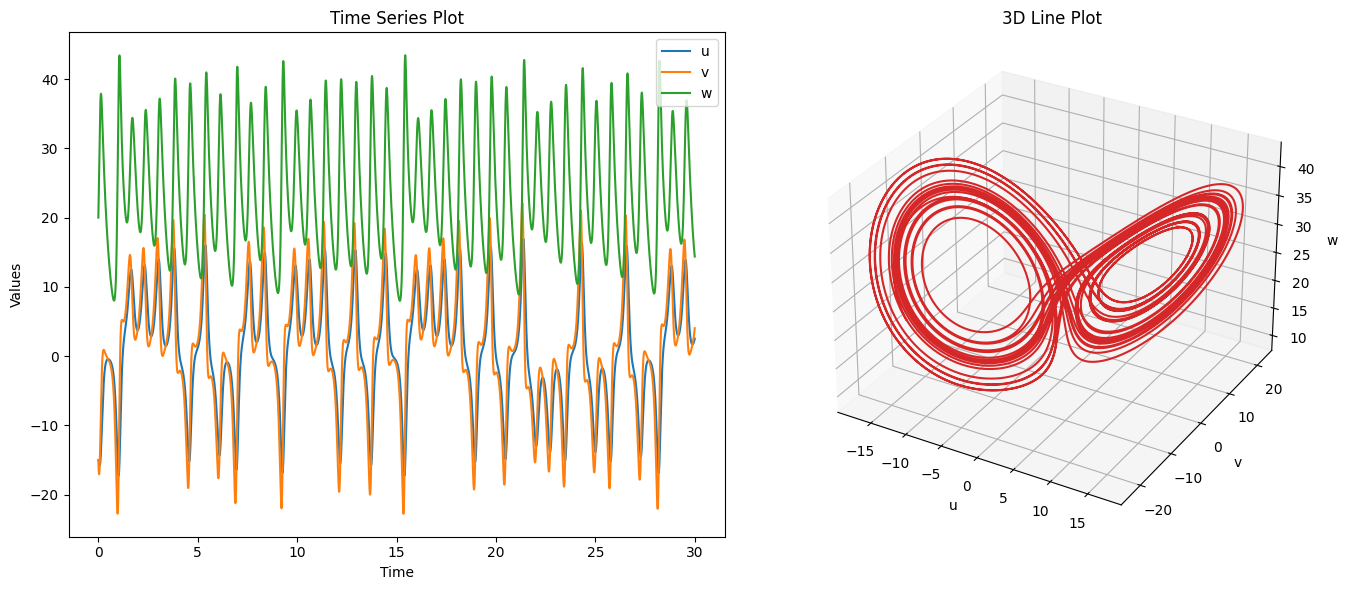

In [5]:
from Capitulo1_metodos import Euler_explicito
u0 = -15.0; v0 = -15.0; w0 = 20 
y0 = (u0,v0,w0)
# Euler
y3, x3 = Euler_explicito(odefun=funsystem3, t_span=(0.0, 30), y0=y0, h=0.001, return_trajectory=True)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Assuming x3, y3, and y2 are already defined

# Create a figure with 2 subplots: 1 for the time series and 1 for the 3D plot
fig = plt.figure(figsize=(14, 6))

# First subplot (time series)
ax1 = fig.add_subplot(121)  # 1 row, 2 columns, 1st subplot
ax1.plot(x3, y3[:,0], '-', label='u')
ax1.plot(x3, y3[:,1], '-', label='v')
ax1.plot(x3, y3[:,2], '-', label='w')
ax1.set_title('Time Series Plot')
ax1.set_xlabel('Time')
ax1.set_ylabel('Values')
ax1.legend()

# Second subplot (phase plot)
ax2 = fig.add_subplot(122, projection='3d')  # 1 row, 2 columns, 2nd subplot

# Plot the 3D line
ax2.plot(y3[:,0], y3[:,1], y3[:,2], color='C03')

# Set labels
ax2.set_xlabel('u')
ax2.set_ylabel('v')
ax2.set_zlabel('w')

# Set a title
ax2.set_title('3D Line Plot')

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the combined figure
plt.show()


4. **Ejemplo no caotico en tres dimensiones**.

Analizado en Bender and Orzag, Advanced Mathematical Methods for Scientist and Engineers, paginas 202-204.

\begin{align*}
\dot{u} & = vw \\
\dot{v} & = -2uw \\
\dot{w} & = uv
\end{align*}

Se puede demostrar que cualquier trayectoria $(u(t),v(t), w(t))$ esta sobre una esfera, es decir que satisfaces que la cantidad $u(t)^{2} + v(t)^{2}+w(t)^{2}$ es constante. 

In [71]:
def funsystem4(t,y):
    u,v,w = y
    F= [v*w, -2.0*u*w, u*v]
    return np.asarray(F)

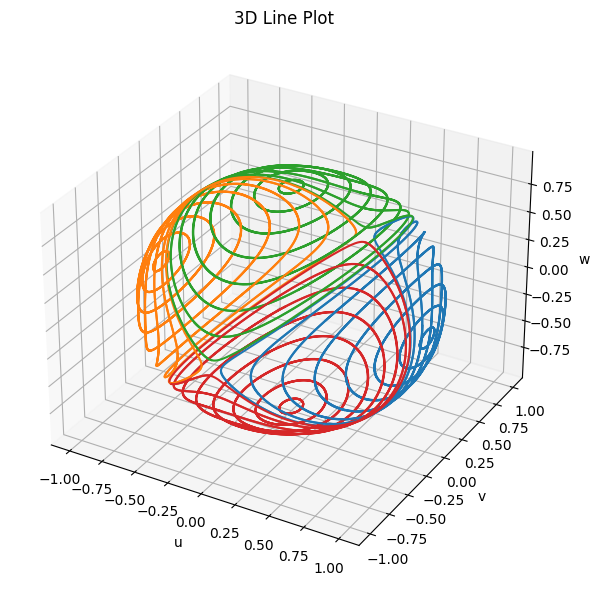

In [75]:
from Capitulo1_metodos import Euler_explicito

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(14, 6))
ax2 = fig.add_subplot(111, projection='3d') 
for theta in np.arange(-1.5,1.7,0.2):
    u0 = np.cos(theta); v0 = np.sin(theta); w0 = 0
    y0 = (u0,v0,w0)
    # Euler
    y4, x4 = Euler_explicito(odefun=funsystem4, t_span=(0.0, 10), y0=y0, h=0.001, return_trajectory=True)

    ax2.plot(y4[:,0], y4[:,1], y4[:,2], color='C00')
    ax2.plot(-y4[:,0], y4[:,1], y4[:,2],color='C01')
    ax2.plot(y4[:,2], y4[:,1], y4[:,0], color='C02')
    ax2.plot(y4[:,2], y4[:,1], -y4[:,0], color='C03')


ax2.set_xlabel('u')
ax2.set_ylabel('v')
ax2.set_zlabel('w')
ax2.set_title('3D Line Plot')
plt.tight_layout()
plt.show()


5. **Modelo SIR para epidemias**

In 1927 W. O. Kermack y A. G. McKendrick propusieron lo que hoy es llamado el modelo SIR para la propagacion de una enfermedad, en particular para el brote the la plaga bubonica en Bombay. (A  contribution to the mathemtical theory of epidemics, Proceedings of the Royal Society of London A). Si bien el modelo SIR es ahora considerado demasiado simple para seguimiento cuantitativo de epidemias reales, exhibe varias propiedades importantes y se mantiene como la base de modelos mas completo.

Este es un modelo por compartimentos, en el cual uno imagina miembros de una poblacion haciendo la transicion continuamete desde una caja etiquetada $S$ por susceptible a otro caja $I$ por infectado y eventualemente a una caja $R$ por recuperados or removed (posiblemente fallecidos). En forma a-dimensional el sistema es 
\begin{align*}
\dot{S} & = -\beta SI \\
\dot{I} & = (\beta S-\gamma)I \\
\dot{R} & = \gamma I 
\end{align*}
donde $\beta, \gamma> 0$ son parametros y $S(t)$, $I(t)$ y $R(t)$ denotan las proporciones de la poblacion en los tres compartimentos. Las condiciones iniciales $S(0) = 1- I_0$, $I(0) = I_0$, $R(0) = 0$ 

In [22]:
def funsystem5(t,y, beta=2.0, gamma=1.0):
    S,I,R = y
    F= [-beta*S*I, (beta*S-gamma)*I, gamma*I]
    return np.asarray(F)

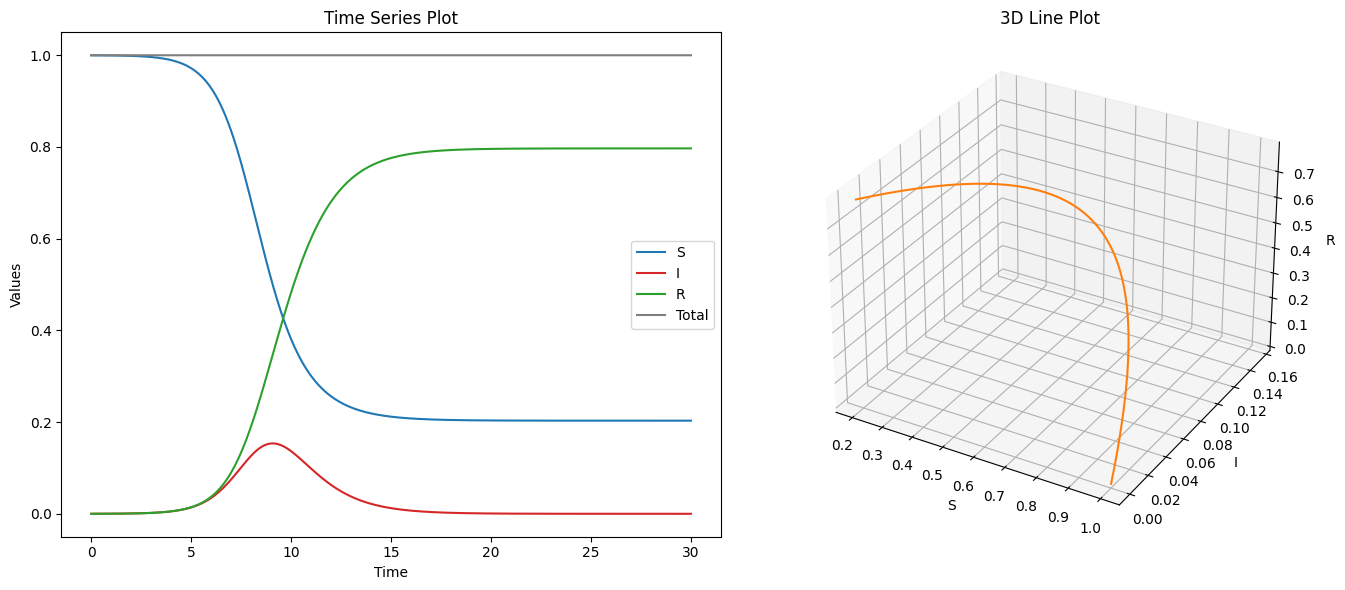

In [23]:
from Capitulo1_metodos import Euler_explicito
I0 = 0.0001; R0 = 0 
S0 = 1-I0;
y0 = (S0,I0,R0)
# Euler
y5, x5 = Euler_explicito(odefun=funsystem5, t_span=(0.0, 30), y0=y0, h=0.001, return_trajectory=True)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# Create a figure with 2 subplots: 1 for the time series and 1 for the 3D plot
fig = plt.figure(figsize=(14, 6))

# First subplot (time series)
ax1 = fig.add_subplot(121)  # 1 row, 2 columns, 1st subplot
ax1.plot(x5, y5[:,0], '-', label='S')
ax1.plot(x5, y5[:,1], '-', label='I', color='C03')
ax1.plot(x5, y5[:,2], '-', label='R', color='C02')
ax1.plot(x5, y5[:,0]+y5[:,1]+y5[:,2], '-', label='Total', color='C07')
ax1.set_title('Time Series Plot')
ax1.set_xlabel('Time')
ax1.set_ylabel('Values')
ax1.legend()

# Second subplot (phase plot)
ax2 = fig.add_subplot(122, projection='3d')  # 1 row, 2 columns, 2nd subplot

# Plot the 3D line
ax2.plot(y5[:,0], y5[:,1], y5[:,2], color='C01')

# Set labels
ax2.set_xlabel('S')
ax2.set_ylabel('I')
ax2.set_zlabel('R')

# Set a title
ax2.set_title('3D Line Plot')

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the combined figure
plt.show()


In [ ]:
from Capitulo1_metodos import Euler_explicito
I0 = 0.0001; R0 = 0 
S0 = 1-I0;
y0 = (S0,I0,R0)
# Euler
betas = [1.3, 1.6, 2.0, 2.8, 3.4]
for beta in betas:
    odefun = lambda t, y: funsystem5(t,y,beta=beta)
    y5, x5 = Euler_explicito(odefun, t_span=(0.0, 40), y0=y0, h=0.001, return_trajectory=True)

    plt.plot(x5, y5[:,1], '-', label='beta='+str(beta))

plt.title('Evolucion de infectados')
plt.legend()
plt.tight_layout()

# Show the combined figure
plt.show()


---
## Problemas rigidos o Stiff
## Clase 5: 

### Ejemplo de problema stiff trivial
\begin{equation}
y' = \lambda y, \quad y(0) = 1, \quad \lambda = -20. \quad \mbox{Solucion: } y(x) = \exp(-20 x)
\end{equation}


C:\Users\Manuel Sánchez\Documents\GitHub\ManuelSanchezUribe.github.io\IMT3410\Capitulo1_metodos.py:52: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  if return_trajectory: return (np.array(yh),np.array(tn))


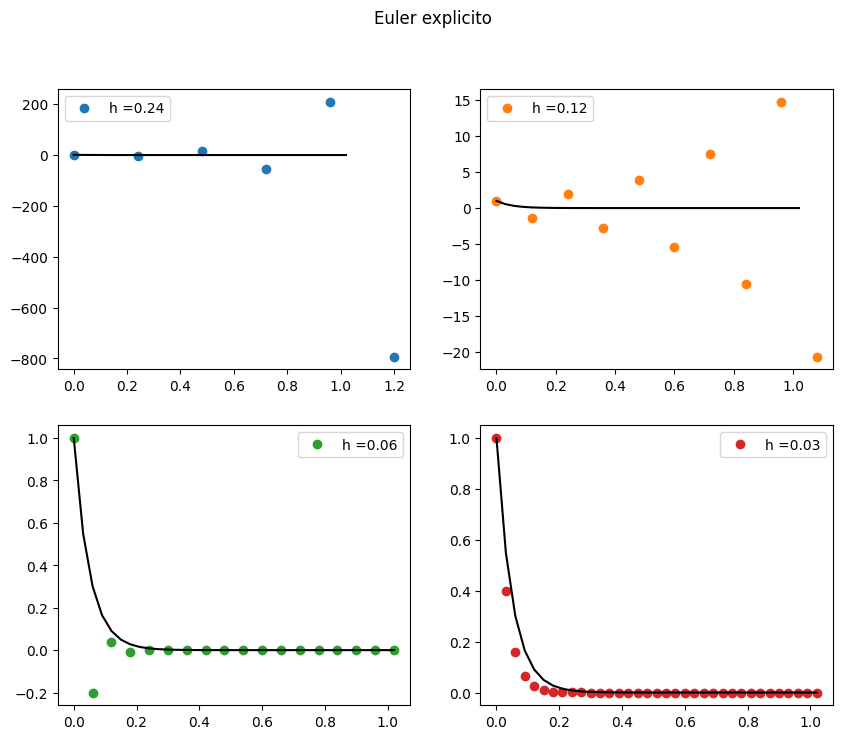

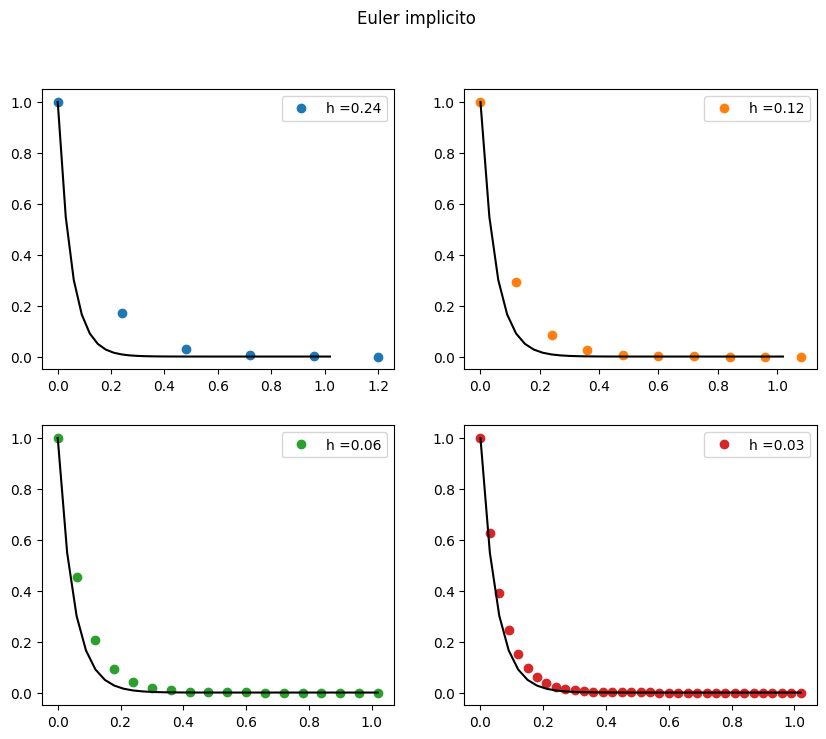

In [3]:
from Capitulo1_metodos import Euler_explicito, Euler_implicito

fstiff1 = lambda x,y : -20*y
# dfstiff1dy = lambda x,y: -20
y0 = 1
XM = 1
h = [0.24, 0.12, 0.06, 0.03]
N = [int(XM/hi) for hi in h]

yexact = lambda x: np.exp(-20*x)
YH = []
XH = []
YHi = []
# Euler
for i,hi in enumerate(h):
    yh,  xh = Euler_explicito(odefun=fstiff1, t_span=(0.0, XM), y0=y0, h=h[i], return_trajectory=True)
    yhi, xh = Euler_implicito(odefun=fstiff1, t_span=(0.0, XM), y0=y0, h=h[i], return_trajectory=True)
    YH.append(yh)
    XH.append(xh)
    YHi.append(yhi)

fig, ax = plt.subplots(2,2, figsize=(10,8))
fig.suptitle('Euler explicito')
ax[0,0].plot(XH[0],YH[0], 'o', color='C00',label='h =%.2f'%h[0])
ax[0,0].plot(XH[3], yexact(np.asarray(XH[3])),'k')
ax[0,0].legend()
ax[0,1].plot(XH[1],YH[1], 'o', color='C01',label='h =%.2f'%h[1])
ax[0,1].plot(XH[3], yexact(np.asarray(XH[3])),'k')
ax[0,1].legend()
ax[1,0].plot(XH[2],YH[2], 'o', color='C02',label='h =%.2f'%h[2])
ax[1,0].plot(XH[3], yexact(np.asarray(XH[3])),'k')
ax[1,0].legend()
ax[1,1].plot(XH[3],YH[3], 'o', color='C03',label='h =%.2f'%h[3])
ax[1,1].plot(XH[3], yexact(np.asarray(XH[3])),'k')
ax[1,1].legend()
plt.show()

figi, axi = plt.subplots(2,2, figsize=(10,8))
figi.suptitle('Euler implicito')
axi[0,0].plot(XH[0],YHi[0], 'o', color='C00',label='h =%.2f'%h[0])
axi[0,0].plot(XH[3], yexact(np.asarray(XH[3])),'k')
axi[0,0].legend()
axi[0,1].plot(XH[1],YHi[1], 'o', color='C01',label='h =%.2f'%h[1])
axi[0,1].plot(XH[3], yexact(np.asarray(XH[3])),'k')
axi[0,1].legend()
axi[1,0].plot(XH[2],YHi[2], 'o', color='C02',label='h =%.2f'%h[2])
axi[1,0].plot(XH[3], yexact(np.asarray(XH[3])),'k')
axi[1,0].legend()
axi[1,1].plot(XH[3],YHi[3], 'o', color='C03',label='h =%.2f'%h[3])
axi[1,1].plot(XH[3], yexact(np.asarray(XH[3])),'k')
axi[1,1].legend()
plt.show()


### Ejemplo de problema stiff sistema
\begin{equation}
y' = A y, \quad y(0) = \begin{bmatrix} 1 \\4 \end{bmatrix}, \quad 
A= 
\begin{bmatrix}
-8003 & 1999 \\
23988 & -6004 
\end{bmatrix}.
 \quad \mbox{Solucion: } y(x) = \begin{bmatrix}\exp(-7 x) \\ 4 \exp(-7x)\end{bmatrix}
\end{equation}


In [4]:
A = np.array([[-8003, 1999],[23988, -6004]], dtype=np.float64)
eigenvaluesA, eigenvectorsA = np.linalg.eig(A)
print(eigenvaluesA)

[-1.4e+04 -7.0e+00]


In [5]:
Fstiff1 = lambda x, Y: A.dot(Y)
dFstiff1dy = lambda x, Y: A 

Y0 = np.array([1.0,4.0], dtype=np.float64)
XM = 0.08
# XM= 0.008
h = [0.004]
N = [20]

Yexact = lambda x: np.array([np.exp(-7*x), 4*np.exp(-7*x)])
YH = []
XH = []
YHi = []
# Euler
for i,hi in enumerate(h):
    yh,  xh = Euler_explicito(odefun=Fstiff1, t_span=(0.0, XM), y0=Y0, h=h[i], return_trajectory=True)
    yhi, xh = Euler_implicito(odefun=Fstiff1, t_span=(0.0, XM), y0=Y0, h=h[i], return_trajectory=True)

    YH.append(yh)
    XH.append(xh)
    YHi.append(yhi)

df = pd.DataFrame({'x': xh, 'y_1':[Yexact(xhi)[0] for xhi in xh], 'Euler Explicito':np.asarray(yh)[:,0], 'Euler implicito':np.asarray(yhi)[:,0]})
df

,x,y_1,Euler Explicito,Euler implicito
0,0.000,1.000000,1.000000e+00,1.000000
1,0.004,0.972388,9.720000e-01,0.972763
2,0.008,0.945539,9.447840e-01,0.946267
3,0.012,0.919431,9.183300e-01,0.920493
4,0.016,0.894044,8.926168e-01,0.895422
5,0.020,0.869358,8.676235e-01,0.871033
6,0.024,0.845354,8.433301e-01,0.847308
7,0.028,0.822012,8.197168e-01,0.824230
8,0.032,0.799315,7.967648e-01,0.801780
9,0.036,0.777245,7.744553e-01,0.779941


## Region de estabilidad

In [8]:
from Capitulo1_metodos import plot_stability_region_multistep

### Region de estabilidad del metodo de Euler explicito

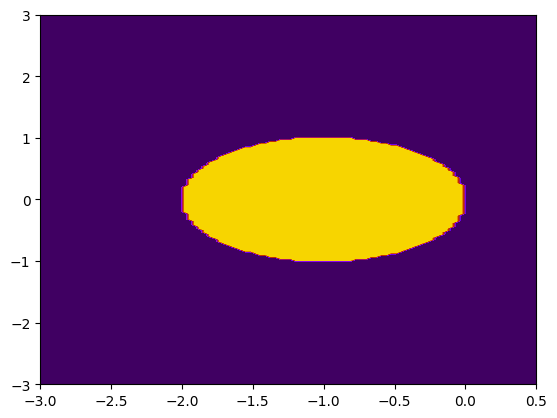

In [9]:
# Coeficientes del metodo de Euler explicito
a = [-1.0,1.0]
b = [1.0,.0]
A_eulerexplicito = plot_stability_region_multistep(a,b)

### Region de estabilidad del metodo de Euler implicito

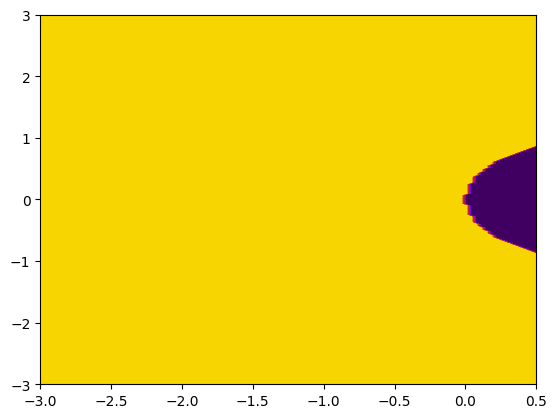

In [10]:
# Euler implicito
a = [-1.0,1.0]
b = [0,1.0]
A_implicito = plot_stability_region_multistep(a,b)

### Region de estabilidad de la regla trapezoidal

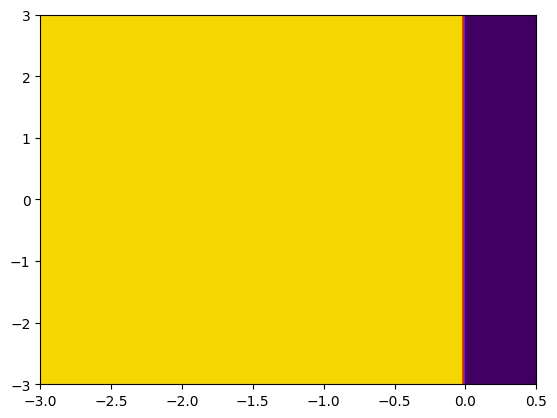

In [11]:
# trapezoidal
a = [-1.0,1.0]
b = [1.0/2.0,1.0/2.0]
A_trap = plot_stability_region_multistep(a,b)

### Region de estabilidad del metodo de Adams-Bashforth 2

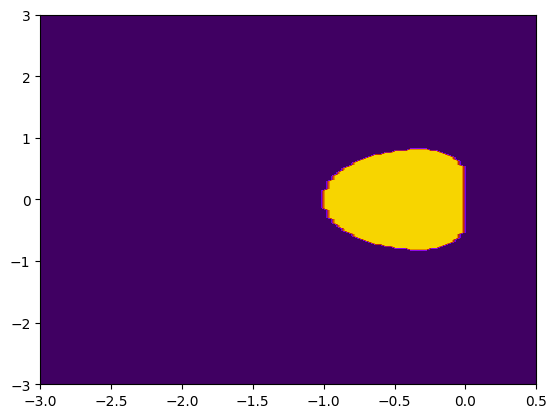

In [12]:
# A-B2
a = [0,-1.0,1.0]
b = [-1.0/2.0,3.0/2.0,0]
A_AB2 = plot_stability_region_multistep(a,b)

### Region de estabilidad del metodo de Adams-Moulton 2

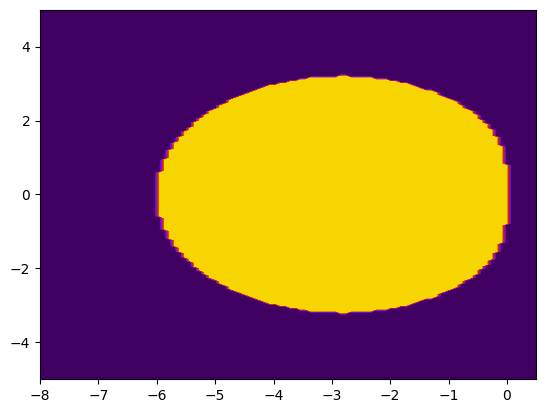

In [13]:
# A-M2
a = [0,-1.0,1.0]
b = [-1.0/12.0,2.0/3.0,5.0/12.0]
A_AM2 = plot_stability_region_multistep(a,b,xinter=[-8,0.5], yinter=[-5,5])

### Region de estabilidad del metodo BDF2

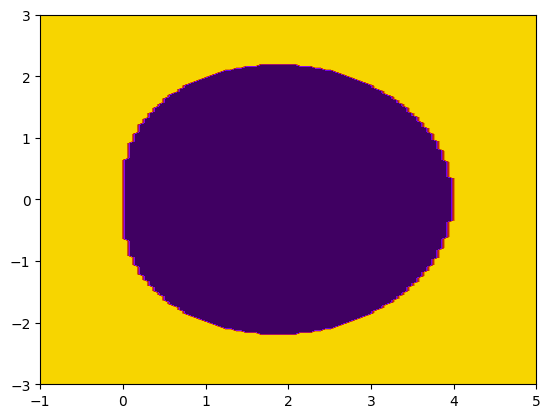

In [14]:
# BDF2 
a = [1,-4.0,3.0]
b = [0,0,2]
A_BDF2 = plot_stability_region_multistep(a,b,xinter=[-1,5], yinter=[-3,3])

### Region de estabilidad del metodo BDF5

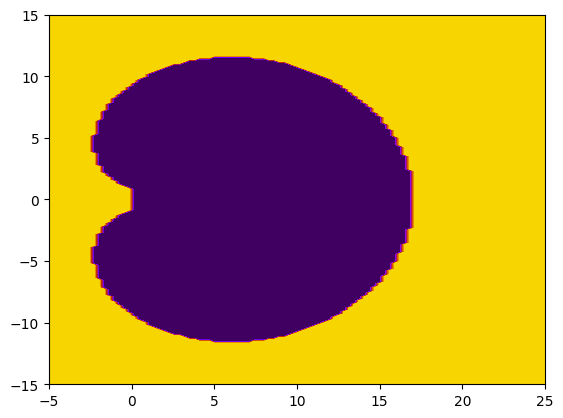

In [15]:
# BDF5 
a = [-12, 75,-200,300,-300,137]
b = [0,0,0,0,0,60]
A_BDF5 = plot_stability_region_multistep(a,b,xinter=[-5,25], yinter=[-15,15])

## Ejemplo: sistema stiff

Considere el sistema lineal de ecuaciones diferenciales
$$
y' = Ly = (V D V^{-1}) y; \quad 
L = 
\begin{bmatrix} -100 & 1 \\ 0 &-0.1 \end{bmatrix}
=
\begin{bmatrix} 1.0 & 1.0 \\ 0 & 99.9 \end{bmatrix}
\begin{bmatrix} -100 & .0 \\ 0 & -0.1 \end{bmatrix}
\begin{bmatrix} 1.0 & 1.0 \\ 0 & 99.9 \end{bmatrix}^{-1}
$$
y la condicion inicial
$$
y(0) = y_0 = \begin{bmatrix} 1.0 \\ 99.9 \end{bmatrix}
$$

In [4]:
L = np.array([[-100.0,1.0],[0,-0.1]])
V = np.array([[1.0,1.0],[0,99.9]])
D = np.array([[-100.0,0.0],[0,-0.1]])
print(np.linalg.inv(V))
print(L-V@D@np.linalg.inv(V))

[[ 1.         -0.01001001]
 [ 0.          0.01001001]]
[[0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.38777878e-17]]


c:\users\manuel sánchez\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:12: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  if sys.path[0] == "":


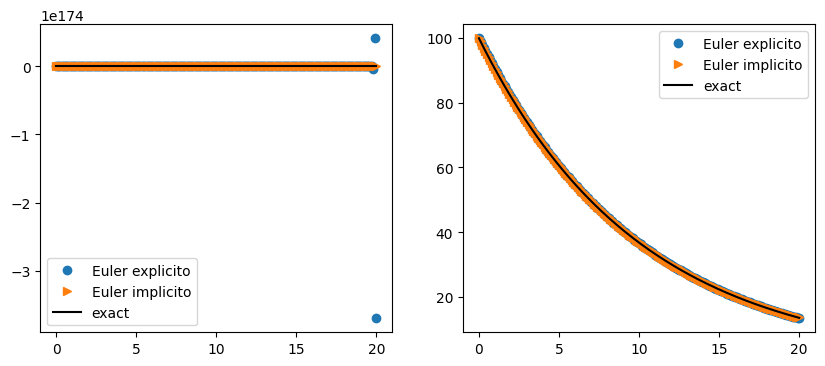

In [16]:
from Capitulo1_metodos import Euler_explicito, Euler_implicito
import matplotlib.pyplot as plt
Fstiff2 = lambda x, Y: L.dot(Y)
dFstiff2dy = lambda x, Y: L 

Y0 = np.array([1.0,99.9], dtype=np.float64)

h = 0.1
N = 200
XM = h*N

Yexact = lambda x: V@np.array([[np.exp(-100*x),0],[0, np.exp(-0.1*x)]])@np.linalg.solve(V,Y0)
YH = []
XH = []
YHi = []
# Euler
yh, xh = Euler_explicito(odefun=Fstiff2, t_span=(0.0, XM), y0=Y0, h=h, return_trajectory=True)
yhi, xh = Euler_implicito(odefun=Fstiff2, t_span=(0.0, XM), y0=Y0, h=h, return_trajectory=True)
    
YH.append(yh)
XH.append(xh)
YHi.append(yhi)

# df = pd.DataFrame({'x': xh, 'y_1':[Yexact(xhi)[0] for xhi in xh], 'Euler Explicito':np.asarray(yh)[:,0], 'Euler implicito':np.asarray(yhi)[:,0]})
# df

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(xh, yh[:,0], 'o', color='C00',label='Euler explicito')
ax[0].plot(xh, np.array(yhi)[:,0], '>',color='C01', label='Euler implicito')
xplot = np.linspace(0,XM, 200)
ax[0].plot(xplot, Yexact(xplot)[0], color='k', label='exact')
ax[0].legend()

ax[1].plot(xh, yh[:,1], 'o', color='C00',label='Euler explicito')
ax[1].plot(xh, np.array(yhi)[:,1], '>',color='C01', label='Euler implicito')
xplot = np.linspace(0,XM, 200)
ax[1].plot(xplot, Yexact(xplot)[1], color='k', label='exact')
ax[1].legend()
plt.show()